**The ipynb file for making the regional masks for Peruvian Coast region**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 06/01/2026
- Latest modified: 06/01/2026

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
import scipy.spatial as spatial
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyicon as pyic
import shapely as shp
import shapely.geometry as shpg

import os


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [2]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

# Atmospheric grid

## Peruvian Coast General Mask

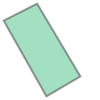

In [3]:
PC_gen_path = "/home/m/m301254/project_surfwaves/docs/version2/Peruvian_Coast_General.txt"

PC_gen_shape = shpg.Polygon(np.loadtxt(PC_gen_path, delimiter=","))
PC_gen_shape

In [4]:
# read an atmospheric mask
ds_atm = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0001_b5b7/outdata/mux0001_b5b7_atm_2d_13000101T000000Z.nc')

/tmp/ipykernel_1566129/1354252059.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_atm = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0001_b5b7/outdata/mux0001_b5b7_atm_2d_13000101T000000Z.nc')


In [5]:
ds_atm

<xarray.Dataset> Size: 733MB
Dimensions:        (ncells: 81920, vertices: 3, time: 60, height: 1, height_2: 1)
Coordinates:
  * time           (time) object 480B 1300-02-01 00:00:00 ... 1305-01-01 00:0...
  * height         (height) float64 8B 10.0
  * height_2       (height_2) float64 8B 2.0
    clon           (ncells) float64 655kB ...
    clat           (ncells) float64 655kB ...
Dimensions without coordinates: ncells, vertices
Data variables: (12/40)
    clon_bnds      (ncells, vertices) float64 2MB ...
    clat_bnds      (ncells, vertices) float64 2MB ...
    pres_msl       (time, ncells) float32 20MB ...
    pres_sfc       (time, ncells) float32 20MB ...
    t_s            (time, ncells) float32 20MB ...
    clct           (time, ncells) float32 20MB ...
    ...             ...
    t_ice          (time, ncells) float32 20MB ...
    h_ice          (time, ncells) float32 20MB ...
    albvisdif      (time, ncells) float32 20MB ...
    albvisdir      (time, ncells) float32 20MB ...
    albnirdif      (time, ncells) float32 20MB ...
    albnirdir      (time, ncells) float32 20MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.2.4 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  30
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/ic...
    uuidOfHGrid:          a668eac0-fe2e-11e4-9a47-e3e5371a87a7
    source:               version: 2025.04; revision: icon-2025.04-223-g3f064...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    history:              Sat Dec 06 05:49:35 2025: cdo -r -O -z zstd clone /...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l20030 (Linux 4.18.0-553.74.1...
    CDO:                  Climate Data Operators version 2.2.2 (https://mpime...

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: >,
  <matplotlib.colorbar.Colorbar at 0x7fe8dc955b10>])

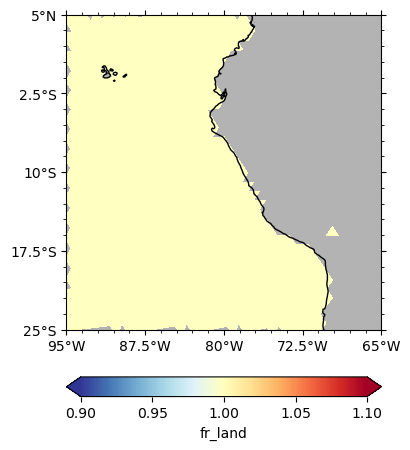

In [5]:
# create a mask that specifies the ocean points near the Peruvian coast
water_mask_atmgrid = xr.where(np.logical_or(ds_atm['fr_land'].isnull(), ds_atm['fr_land'] < 0.5), 1.0, 0.0)

water_mask_atmgrid.pyic.plot(fpath_tgrid=fpath_tgrid['atm'], 
                   fpath_ckdtree=fpath_ckdtree['atm'],
                   land_facecolor='none',
                   plot_method='tgrid',
                   lon_reg = [-95, -65],
                   lat_reg = [-25, 5],
)

In [6]:
water_mask_atmgrid

<xarray.DataArray 'fr_land' (ncells: 81920)> Size: 655kB
array([1., 1., 1., ..., 1., 1., 1.], shape=(81920,))
Coordinates:
    clon     (ncells) float64 655kB 1.257 0.8771 1.257 ... 0.01083 0.00623
    clat     (ncells) float64 655kB 1.561 1.547 1.554 ... -0.4769 -0.4713
Dimensions without coordinates: ncells

In [7]:
# select the region that is within the shape
PC_gen_mask = water_mask_atmgrid.squeeze().copy().compute()

points = np.column_stack(
    (
        PC_gen_mask.clon.values * 180 / np.pi,
        PC_gen_mask.clat.values * 180 / np.pi,
    )
)

for i, (lon, lat) in enumerate(points):
    point = shpg.Point(lon, lat)
    if not PC_gen_shape.contains(point):
        PC_gen_mask[i] = 0.0
    else:
        # print(f"Point {i} is within the shape.")
        PC_gen_mask[i] = water_mask_atmgrid[i].values


(81920,)
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


/tmp/ipykernel_1566129/311524164.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


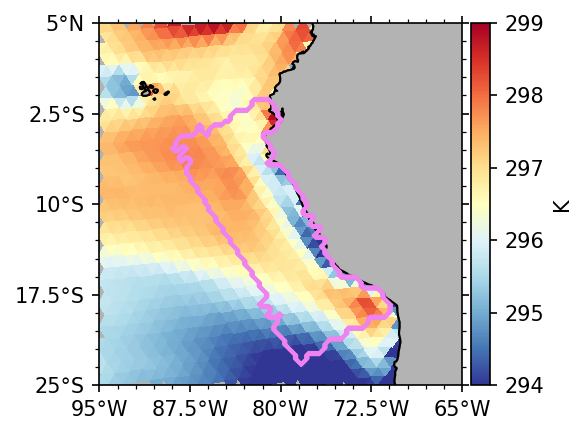

In [8]:
# use the atmospheric variables to check the mask
t_2m_test = ds_atm['t_2m'].isel(time=0, height_2=0)
print(t_2m_test.shape)

# plotting
fig, ax = plt.subplots(figsize=(4,3), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})

ax, hm = t_2m_test.pyic.plot(
    ax=ax,
    cax=0,
    fpath_tgrid=fpath_tgrid['atm'],
    fpath_ckdtree=fpath_ckdtree['atm'],
    # cmap='Blues',
    # land_facecolor='none',
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    plot_method='tgrid',
    clim=[294,299],
)

ax, ct = (PC_gen_mask + 1).pyic.plot(
    ax=ax,
    cax=0,
    fpath_tgrid=fpath_tgrid['atm'],
    fpath_ckdtree=fpath_ckdtree['atm'],
    # land_facecolor='none',
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    # plot_method='tgrid',
    use_pcol_or_contf=False,
    conts=1.0,
    contcolor='violet',
)

cbar = fig.colorbar(hm[0], ax=ax, orientation='vertical', label="K", pad=0.02)
for line in ct:
    line.set_linewidths(1.0)
    line.set_zorder(5)
fig.tight_layout()
fig.show()

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


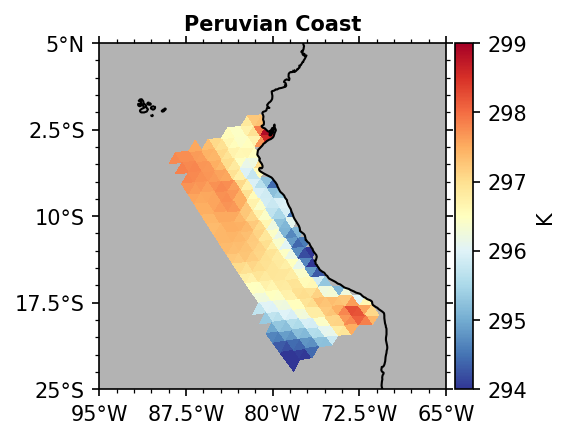

In [9]:
t_2m_masked = t_2m_test.where(PC_gen_mask == 1.0)

# plotting
fig, ax = plt.subplots(figsize=(4,3), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})

ax, hm = t_2m_masked.pyic.plot(
    ax=ax,
    cax=0,
    fpath_tgrid=fpath_tgrid['atm'],
    fpath_ckdtree=fpath_ckdtree['atm'],
    # cmap='Blues',
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    plot_method='tgrid',
    clim=[294,299],
    title_right="",
)
ax.set_title("Peruvian Coast", fontsize=10, fontweight='bold')
cbar = fig.colorbar(hm[0], ax=ax, orientation='vertical', label="K", pad=0.02)

## Separate the general mask into northern, middle, southern, and NearShore components

In [10]:
# paths
PC_nor_path = "/home/m/m301254/project_surfwaves/docs/version2/Peruvian_Coast_North.txt"
PC_sou_path = "/home/m/m301254/project_surfwaves/docs/version2/Peruvian_Coast_South.txt"
PC_mid_path = "/home/m/m301254/project_surfwaves/docs/version2/Peruvian_Coast_Middle.txt"
PC_sho_path = "/home/m/m301254/project_surfwaves/docs/version2/Peruvian_nearshore.txt"
PC_alo_path = "/home/m/m301254/project_surfwaves/docs/version2/Peruvian_alongshore.txt"

# shapes
PC_nor_shape = shpg.Polygon(np.loadtxt(PC_nor_path, delimiter=","))
PC_sou_shape = shpg.Polygon(np.loadtxt(PC_sou_path, delimiter=","))
PC_mid_shape = shpg.Polygon(np.loadtxt(PC_mid_path, delimiter=","))
PC_sho_shape = shpg.Polygon(np.loadtxt(PC_sho_path, delimiter=","))
PC_alo_shape = shpg.Polygon(np.loadtxt(PC_alo_path, delimiter=","))

### Function to create atmospheric mask 
- based on shape file and water mask for atmospheric/ocean grid

In [11]:
# function to create mask
def make_atm_mask(shape_file, water_mask):
    '''
    the function to create the mask file for atmospheric grid from a shape file and the water mask, created from the land fraction dataset
    '''
    regional_mask = water_mask.squeeze().copy().compute()
    points = np.column_stack(
        (
            regional_mask.clon.values * 180 / np.pi,
            regional_mask.clat.values * 180 / np.pi,
        )
    )
    for i, (lon, lat) in enumerate(points):
        point = shpg.Point(lon, lat)
        if not shape_file.contains(point):
            regional_mask[i] = 0.0
        else:
            # print(f"Point {i} is within the shape.")
            regional_mask[i] = water_mask[i].values

    return regional_mask

In [12]:
# apply the funtion to create masks
PC_nor_mask = make_atm_mask(PC_nor_shape, water_mask_atmgrid)
PC_mid_mask = make_atm_mask(PC_mid_shape, water_mask_atmgrid)
PC_sou_mask = make_atm_mask(PC_sou_shape, water_mask_atmgrid)
PC_sho_mask = make_atm_mask(PC_sho_shape, water_mask_atmgrid)
PC_alo_mask = make_atm_mask(PC_alo_shape, water_mask_atmgrid)

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


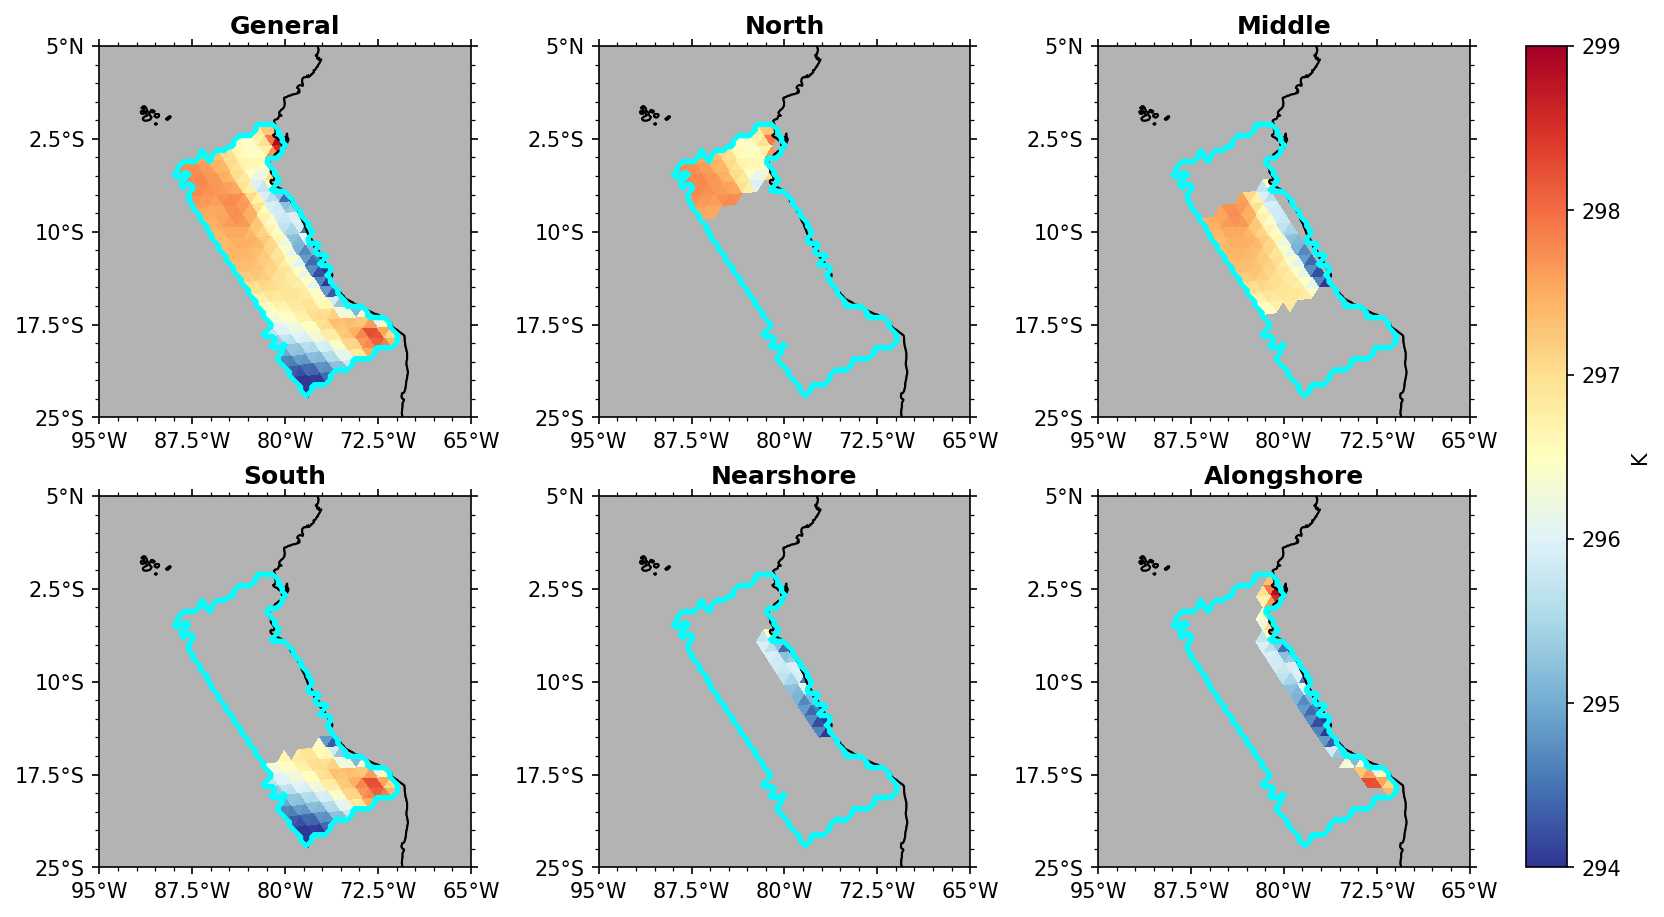

In [13]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(11, 6),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()
masks = {'General': PC_gen_mask,
         'North': PC_nor_mask,
         'Middle': PC_mid_mask,
         'South': PC_sou_mask,
         'Nearshore': PC_sho_mask,
         'Alongshore': PC_alo_mask,}

hm_all = []
for ax, (name, mask) in zip(axes, masks.items()):
    t_2m_masked = t_2m_test.where(mask == 1.0)
    ax, hm = t_2m_masked.pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        plot_method='tgrid',
        clim=[294, 299],
        land_facecolor='none',
        title_right="",
    )
    hm_all.append(hm)
    # General boundary overlay
    ax, ct = (PC_gen_mask + 1).pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        use_pcol_or_contf=False,
        conts=1.0,
        contcolor='cyan',
    )
    for line in ct:
        line.set_linewidths(1.0)
        line.set_zorder(5)
    ax.set_title(name, fontsize=12, fontweight='bold')

for line in ct:
    line.set_linewidths(1.0)
    line.set_zorder(5)

cbar = fig.colorbar(hm_all[0][0], ax=axes, orientation='vertical', label="K", pad=0.02, ) 
outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Peruvian_Coast_Atm-grid_Masks.png" 
# plt.savefig(outfile, dpi=300, bbox_inches="tight") 
# plt.show()

### Save to DataArray

In [14]:
# the dataset for the masks in atmospheric grid
ds_mask_atm = xr.Dataset()
# general mask
ds_mask_atm['pc_all'] = xr.DataArray(
    PC_gen_mask.values,
    dims=PC_gen_mask.dims,
    coords=PC_gen_mask.coords,
    attrs={'standard_name': 'peru_coast_mask',
           'long_name': 'Regional mask for the Peruvian Coast in r2b5 atmospheric grid, ignoring the land points where the fraction of the land is larger than 50%',
           'CDI_grid_type': 'unstructured',
    }
)
# northern component
ds_mask_atm['pc_north'] = xr.DataArray(
    PC_nor_mask.values,
    dims=PC_nor_mask.dims,
    coords=PC_nor_mask.coords,
    attrs={
        'standard_name': 'northern_peru_coast_mask',
        'long_name': 'Regional mask for the northern Peruvian Coast in r2b5 atmospheric grid, ignoring the land points where the fraction of the land is larger than 50%',
        'CDI_grid_type': 'unstructured',
    }
)
# southern component
ds_mask_atm['pc_south'] = xr.DataArray(
    PC_sou_mask.values,
    dims=PC_sou_mask.dims,
    coords=PC_sou_mask.coords,
    attrs={
        'standard_name': 'southern_peru_coast_mask',
        'long_name': 'Regional mask for the southern Peruvian Coast in r2b5 atmospheric grid, ignoring the land points where the fraction of the land is larger than 50%',
        'CDI_grid_type': 'unstructured',
    }
)
# middle component
ds_mask_atm['pc_mid'] = xr.DataArray(
    PC_mid_mask.values,
    dims=PC_mid_mask.dims,
    coords=PC_mid_mask.coords,
    attrs={
        'standard_name': 'middle_peru_coast_mask',
        'long_name': 'Regional mask for the middle Peruvian Coast in r2b5 atmospheric grid, ignoring the land points where the fraction of the land is larger than 50%',
        'CDI_grid_type': 'unstructured',
    }
)
# nearshore component
ds_mask_atm['pc_nearshore'] = xr.DataArray(
    PC_sho_mask.values,
    dims=PC_sho_mask.dims,
    coords=PC_sho_mask.coords,
    attrs={
        'standard_name': 'peru_nearshore_mask',
        'long_name': 'Regional mask for the near shore part of Peruvian Coast in r2b5 atmospheric grid, ignoring the land points where the fraction of the land is larger than 50%',
        'CDI_grid_type': 'unstructured',
    }
)
# along shore component
ds_mask_atm['pc_alongshore'] = xr.DataArray(
    PC_alo_mask.values,
    dims=PC_alo_mask.dims,
    coords=PC_alo_mask.coords,
    attrs={
        'standard_name': 'peru_alongshore_mask',
        'long_name': 'Regional mask for the along shore part of Peruvian Coast in r2b5 atmospheric grid, ignoring the land points where the fraction of the land is larger than 50%',
        'CDI_grid_type': 'unstructured',
    }
)

#### Check if overlaps

In [15]:
overlap_nm = (PC_nor_mask == 1) & (PC_mid_mask == 1)
n_overlap = overlap_nm.sum().item()
print("North–Middle overlapping grid points:", n_overlap)

overlap_sm = (PC_sou_mask == 1) & (PC_mid_mask == 1)
s_overlap = overlap_nm.sum().item()
print("South-Middle overlapping grid points:", s_overlap)

North–Middle overlapping grid points: 0
South-Middle overlapping grid points: 0


In [16]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks"
ds_mask_atm.to_netcdf(f"{outpath}/pc_masks_atm_full-dim.nc")

In [17]:
ds_tgrid = xr.open_dataset(fpath_tgrid["atm"])

In [18]:
# get the index only and saved into "contained_cells"
def get_masked_cells_xr(ds_mask, varname):
    mask = ds_mask[varname] > 0
    return ds_mask.ncells.where(mask, drop=True)

cells_pc_all = get_masked_cells_xr(ds_mask_atm, "pc_all")
cells_pc_nor = get_masked_cells_xr(ds_mask_atm, "pc_north")
cells_pc_sou = get_masked_cells_xr(ds_mask_atm, "pc_south")
cells_pc_mid = get_masked_cells_xr(ds_mask_atm, "pc_mid")
cells_pc_nea = get_masked_cells_xr(ds_mask_atm, "pc_nearshore")
cells_pc_alo = get_masked_cells_xr(ds_mask_atm, "pc_alongshore")

cells_pc_all_idx = cells_pc_all.values.astype(int) 
cells_pc_nor_idx = cells_pc_nor.values.astype(int) 
cells_pc_sou_idx = cells_pc_sou.values.astype(int) 
cells_pc_mid_idx = cells_pc_mid.values.astype(int) 
cells_pc_nea_idx = cells_pc_nea.values.astype(int) 
cells_pc_alo_idx = cells_pc_alo.values.astype(int) 

In [19]:
# Dictionary of masks
mask_dict = {
    "pc_all": cells_pc_all_idx,
    "pc_north": cells_pc_nor_idx,
    "pc_south": cells_pc_sou_idx,
    "pc_middle": cells_pc_mid_idx,
    "pc_nearshore": cells_pc_nea_idx,
    "pc_alongshore": cells_pc_alo_idx,
}

# Loop over masks and save
for mask_name, cell_idx in mask_dict.items():
    clon_sel = ds_mask_atm.clon.values[cell_idx]
    clat_sel = ds_mask_atm.clat.values[cell_idx]

    ds_out = xr.Dataset(
        {
            "contained_cells": ("cell", cell_idx),
            "clon": ("cell", clon_sel),
            "clat": ("cell", clat_sel),
        }
    )
    out_dir = "/work/mh0033/m301254/proj_surfwave/masks/"
    out_file = os.path.join(out_dir, f"{mask_name}_mask_atm_r2b5.nc")
    ds_out.to_netcdf(out_file)
    print(f"Saved {mask_name} mask: {len(cell_idx)} cells -> {out_file}")

Saved pc_all mask: 295 cells -> /work/mh0033/m301254/proj_surfwave/masks/pc_all_mask_atm_r2b5.nc
Saved pc_north mask: 65 cells -> /work/mh0033/m301254/proj_surfwave/masks/pc_north_mask_atm_r2b5.nc
Saved pc_south mask: 103 cells -> /work/mh0033/m301254/proj_surfwave/masks/pc_south_mask_atm_r2b5.nc
Saved pc_middle mask: 113 cells -> /work/mh0033/m301254/proj_surfwave/masks/pc_middle_mask_atm_r2b5.nc
Saved pc_nearshore mask: 32 cells -> /work/mh0033/m301254/proj_surfwave/masks/pc_nearshore_mask_atm_r2b5.nc
Saved pc_alongshore mask: 58 cells -> /work/mh0033/m301254/proj_surfwave/masks/pc_alongshore_mask_atm_r2b5.nc


In [20]:
# check the saved dataset structure
pc_all = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/pc_all_mask_atm_r2b5.nc")
pc_all.contained_cells.values

array([32829, 32830, 32831, 32901, 32912, 32913, 32914, 32915, 32916,
       32917, 32918, 32919, 32920, 32921, 32922, 32923, 32924, 32925,
       32926, 32929, 32930, 32931, 32936, 32937, 32938, 32939, 32940,
       32941, 32942, 32943, 32960, 32961, 32962, 32963, 32964, 32965,
       32966, 32967, 32968, 32969, 32970, 32971, 32972, 32973, 32974,
       32975, 32976, 32992, 32993, 32994, 32995, 32996, 32997, 32998,
       32999, 33000, 33001, 33002, 33003, 33004, 33005, 33006, 33007,
       33008, 33009, 33010, 33011, 33012, 33013, 33014, 33015, 33016,
       33017, 33018, 33019, 33020, 33021, 33022, 33023, 33349, 33360,
       33361, 33362, 33363, 33364, 33365, 33366, 33367, 33368, 33369,
       33370, 33371, 33372, 33373, 33374, 33375, 33376, 33379, 33388,
       33391, 33536, 33537, 33538, 33539, 33540, 33541, 33542, 33543,
       33544, 33545, 33546, 33547, 33548, 33549, 33550, 33551, 33552,
       33554, 33555, 33561, 33564, 33566, 33567, 33568, 33569, 33570,
       33571, 33572,

In [21]:
pc_all

<xarray.Dataset> Size: 7kB
Dimensions:          (cell: 295)
Dimensions without coordinates: cell
Data variables:
    contained_cells  (cell) int64 2kB 32829 32830 32831 ... 53184 53185 53186
    clon             (cell) float64 2kB ...
    clat             (cell) float64 2kB ...

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


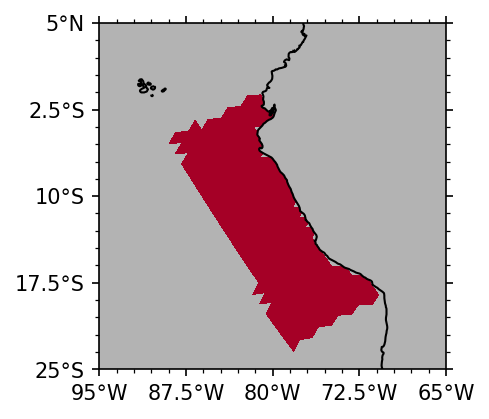

In [22]:
# check if the index is correct
mask_bool = xr.zeros_like(ds_tgrid.cell_area, dtype=bool)
mask_bool[pc_all.contained_cells] = True
masked_area = ds_tgrid.cell_area.where(mask_bool)

fig, ax = plt.subplots(figsize=(4,3), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})
ax, hm = masked_area.pyic.plot(
    ax=ax,
    cax=0,
    fpath_tgrid=fpath_tgrid['atm'],
    fpath_ckdtree=fpath_ckdtree['atm'],
    # cmap='Blues',
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    plot_method='tgrid',
    clim=[294,299],
    title_right="",
)

## Example usage: calculation

In [35]:
def crop_tgrid_to_region(tgrid, mask):
	"""Crop tgrid to the region defined by the mask.
	Parameters
	----------
	tgrid : xarray.Dataset
	The tgrid dataset.
	mask : xarray.DataArray
	The mask defining the region to crop to.

	Returns
	-------
	xarray.Dataset
	The cropped tgrid dataset.
	"""
	# contained_cells: cell index of masked area
	ireg_c = mask["contained_cells"].astype(int)
	crop_tg = pyic.xr_crop_tgrid(tgrid, ireg_c)

	return crop_tg

crop_tg_pc_all = crop_tgrid_to_region(ds_tgrid, pc_all)

find edges
cut coordinates
reindex


In [38]:
ncells_selected = crop_tg_pc_all.cell.rename({"cell": "ncells"})
t_2m_masked = t_2m_test.isel(ncells=ncells_selected)

## Extend the mask to different height levels

In [43]:
# read the original atmospehric file
ds_mask_atm = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_atm_2d.nc")

# file the reference file for atmosphere which has depth coordinate
atm_3d_ref = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0001_b5b7/outdata/mux0001_b5b7_atm_3d_13000101T000000Z.nc")["pres"]

/tmp/ipykernel_54007/3154934665.py:5: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  atm_3d_ref = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/mux0001_b5b7/outdata/mux0001_b5b7_atm_3d_13000101T000000Z.nc")["pres"]


In [46]:
ds_mask_atm

<xarray.Dataset> Size: 5MB
Dimensions:        (ncells: 81920)
Coordinates:
    clon           (ncells) float64 655kB ...
    clat           (ncells) float64 655kB ...
Dimensions without coordinates: ncells
Data variables:
    pc_all         (ncells) float64 655kB ...
    pc_north       (ncells) float64 655kB ...
    pc_south       (ncells) float64 655kB ...
    pc_mid         (ncells) float64 655kB ...
    pc_nearshore   (ncells) float64 655kB ...
    pc_alongshore  (ncells) float64 655kB ...

In [45]:
atm_3d_ref

<xarray.DataArray 'pres' (time: 60, height: 130, ncells: 81920)> Size: 3GB
[638976000 values with dtype=float32]
Coordinates:
  * time     (time) object 480B 1300-02-01 00:00:00 ... 1305-01-01 00:00:00
  * height   (height) float64 1kB 1.0 2.0 3.0 4.0 ... 127.0 128.0 129.0 130.0
    clon     (ncells) float64 655kB ...
    clat     (ncells) float64 655kB ...
Dimensions without coordinates: ncells
Attributes:
    standard_name:                air_pressure
    long_name:                    Pressure
    units:                        Pa
    param:                        0.3.0
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1

In [49]:
# it is called 'height' coordinate
# create new 3d mask dataset
ds_mask_atm_3d = xr.Dataset(
    coords={
        "height": atm_3d_ref.height,
        "ncells": ds_mask_atm.ncells,
        "clon": ds_mask_atm.clon,
        "clat": ds_mask_atm.clat,
    }
)

for v in ds_mask_atm.data_vars:
    # expand (ncells) -> (height, ncells)
    ds_mask_atm_3d[v] = (
        ds_mask_atm[v]
        .expand_dims(height=atm_3d_ref.height)
    )
    # keep the original attrs
    ds_mask_atm_3d[v].attrs = ds_mask_atm[v].attrs

In [51]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks"
ds_mask_atm_3d.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_atm_3d.nc")

# Oceanic grid

In [22]:
ds_mask_atm

<xarray.Dataset> Size: 5MB
Dimensions:        (ncells: 81920)
Coordinates:
    clon           (ncells) float64 655kB 1.257 0.8771 1.257 ... 0.01083 0.00623
    clat           (ncells) float64 655kB 1.561 1.547 1.554 ... -0.4769 -0.4713
Dimensions without coordinates: ncells
Data variables:
    pc_all         (ncells) float64 655kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_north       (ncells) float64 655kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_south       (ncells) float64 655kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_mid         (ncells) float64 655kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_nearshore   (ncells) float64 655kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_alongshore  (ncells) float64 655kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [ ]:
# for ocean grid
ds_mask_oce = xr.Dataset()
oce_grid_ref = xr.open_dataset(fpath_tgrid['oce'])['cell_area']
oce_grid_ref = oce_grid_ref.rename({'cell': 'ncells'})
oce_points = np.column_stack(
    (
        oce_grid_ref.clon.values * 180 / np.pi,
        oce_grid_ref.clat.values * 180 / np.pi,
    )
)

# directory for the shape files and region names
# make sure it is the same as ds_mask_atm
shapes = {'pc_all': PC_gen_shape,
         'pc_north': PC_nor_shape,
         'pc_mid': PC_mid_shape,
         'pc_south': PC_sou_shape,
         'pc_nearshore': PC_sho_shape,
         'pc_alongshore': PC_alo_shape,}

# create masks for ocean grid; different logic from the atmospheric file (water_mask_atmgrid)
for region, shape in shapes.items():
    print(region)
    ds_mask_oce[region] = oce_grid_ref.copy()
    for i, (lon, lat) in enumerate(oce_points):
        point = shpg.Point(lon, lat)
        if shape.contains(point):
            ds_mask_oce[region][i] = 1.0
        else:
            ds_mask_oce[region][i] = 0.0
    ds_mask_oce[region].attrs = ds_mask_atm[region].attrs

pc_all
pc_north
pc_mid
pc_south
pc_nearshore
pc_alongshore


In [31]:
# modify the long_name attribute
ds_mask_oce['pc_all'].attrs={
    'standard_name': 'peru_coast_mask',
    'long_name': 'Regional mask for the Peruvian Coast in r2b7 ocean grid',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_north'].attrs={
    'standard_name': 'north_peru_coast_mask',
    'long_name': 'Regional mask for the northern Peruvian Coast in r2b7 ocean grid',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_south'].attrs={
    'standard_name': 'south_peru_coast_mask',
    'long_name': 'Regional mask for the southern Peruvian Coast in r2b7 ocean grid',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_mid'].attrs={
    'standard_name': 'middle_peru_coast_mask',
    'long_name': 'Regional mask for the middle Peruvian Coast in r2b7 ocean grid',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_nearshore'].attrs={
    'standard_name': 'peru_nearshore_mask',
    'long_name': 'Regional mask for the near shore part of Peruvian Coast in r2b7 ocean grid',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_alongshore'].attrs={
    'standard_name': 'peru_alongshore_mask',
    'long_name': 'Regional mask for the along shore part of Peruvian Coast in r2b7 ocean grid',
    'CDI_grid_type': 'unstructured',
}

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


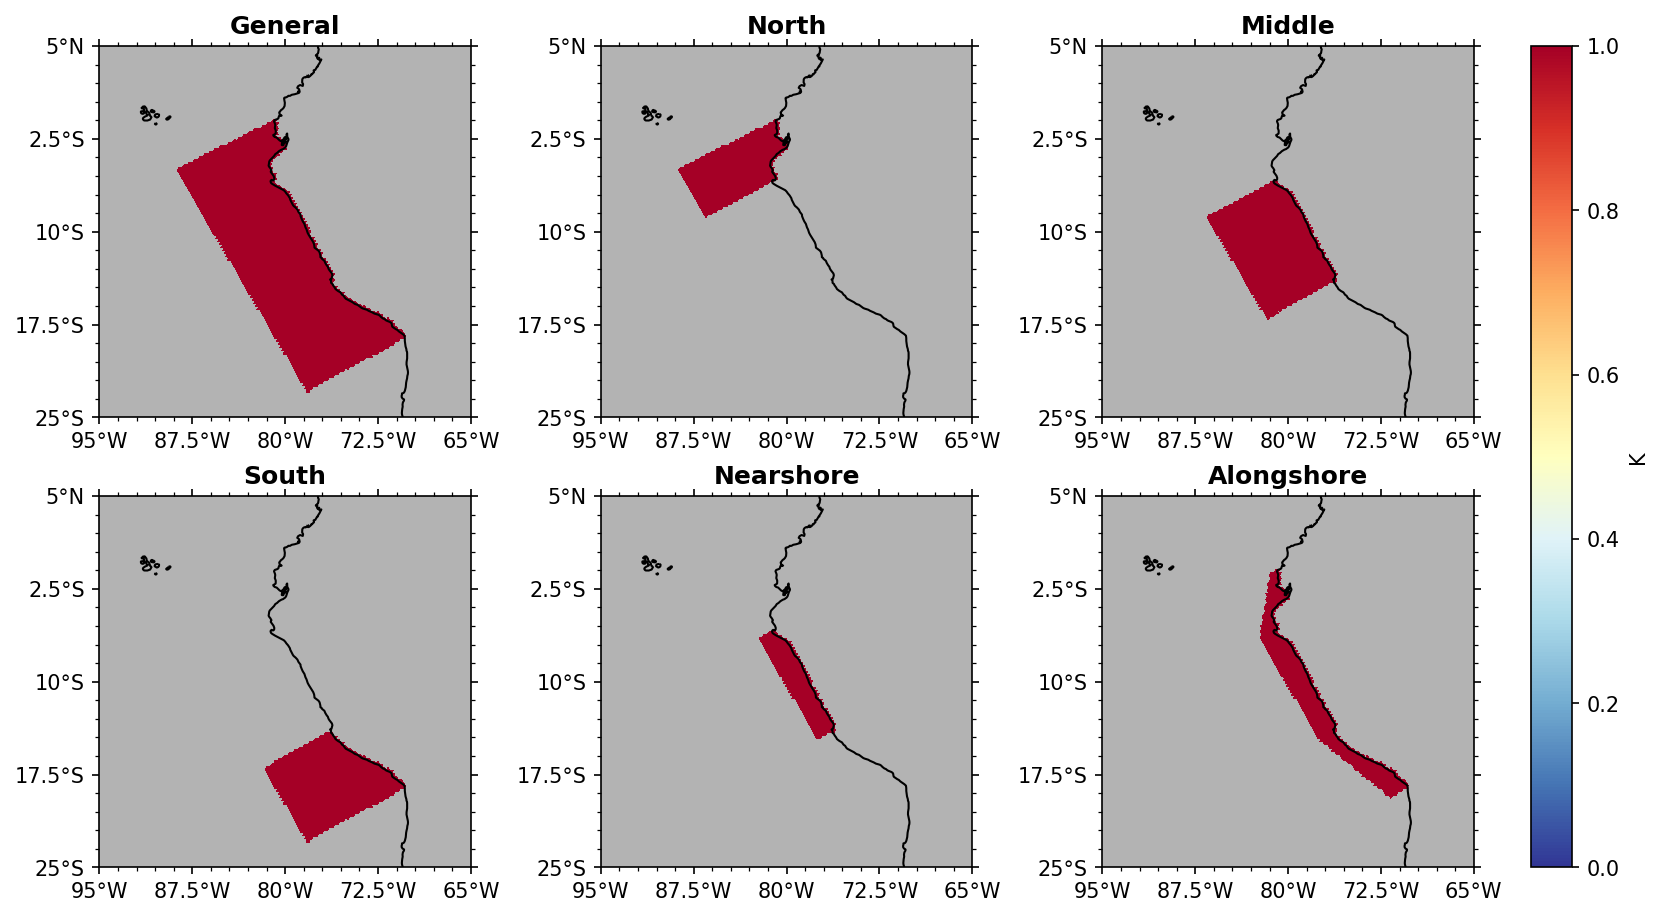

In [43]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(11, 6),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()
masks = {'General': ds_mask_oce['pc_all'],
         'North': ds_mask_oce['pc_north'],
         'Middle': ds_mask_oce['pc_mid'],
         'South': ds_mask_oce['pc_south'],
         'Nearshore': ds_mask_oce['pc_nearshore'],
         'Alongshore': ds_mask_oce['pc_alongshore'],}

hm_all = []
for ax, (name, mask) in zip(axes, masks.items()):
    # t_2m_masked = t_2m_test.where(mask == 1.0)
    ax, hm = mask.pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['oce'],
        fpath_ckdtree=fpath_ckdtree['oce'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        plot_method='tgrid',
        land_facecolor='none',
        title_right="",
        clim=[0, 1],
    )
    hm_all.append(hm)
    ax.set_title(name, fontsize=12, fontweight='bold')


cbar = fig.colorbar(hm_all[0][0], ax=axes, orientation='vertical', label="K", pad=0.02, ) 
outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Peruvian_Coast_Oce-grid_Masks.png" 
# plt.savefig(outfile, dpi=300, bbox_inches="tight") 
# plt.show()

In [44]:
# check the value for the masks
for name, mask in masks.items():
    vals = np.unique(mask.values[~np.isnan(mask.values)])
    print(name, vals)

for name, mask in masks.items():
    print(
        name,
        float(mask.min().values),
        float(mask.max().values)
    )


General [0. 1.]
North [0. 1.]
Middle [0. 1.]
South [0. 1.]
Nearshore [0. 1.]
Alongshore [0. 1.]
General 0.0 1.0
North 0.0 1.0
Middle 0.0 1.0
South 0.0 1.0
Nearshore 0.0 1.0
Alongshore 0.0 1.0


In [ ]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks"
ds_mask_oce.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_oce.nc")

## Limit ocean masks to inner ocean and ocean boundary cells

In [10]:
# read original ocean masks
ds_mask_oce = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce.nc") 
print(ds_mask_oce)

<xarray.Dataset> Size: 60MB
Dimensions:        (ncells: 935760)
Coordinates:
    clon           (ncells) float64 7MB ...
    clat           (ncells) float64 7MB ...
Dimensions without coordinates: ncells
Data variables:
    pc_all         (ncells) float64 7MB ...
    pc_north       (ncells) float64 7MB ...
    pc_mid         (ncells) float64 7MB ...
    pc_south       (ncells) float64 7MB ...
    pc_nearshore   (ncells) float64 7MB ...
    pc_alongshore  (ncells) float64 7MB ...


### Before correction

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...


/tmp/ipykernel_1690605/4173736613.py:29: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  tos_test = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_2d_1330-1345.nc')['tos']


Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


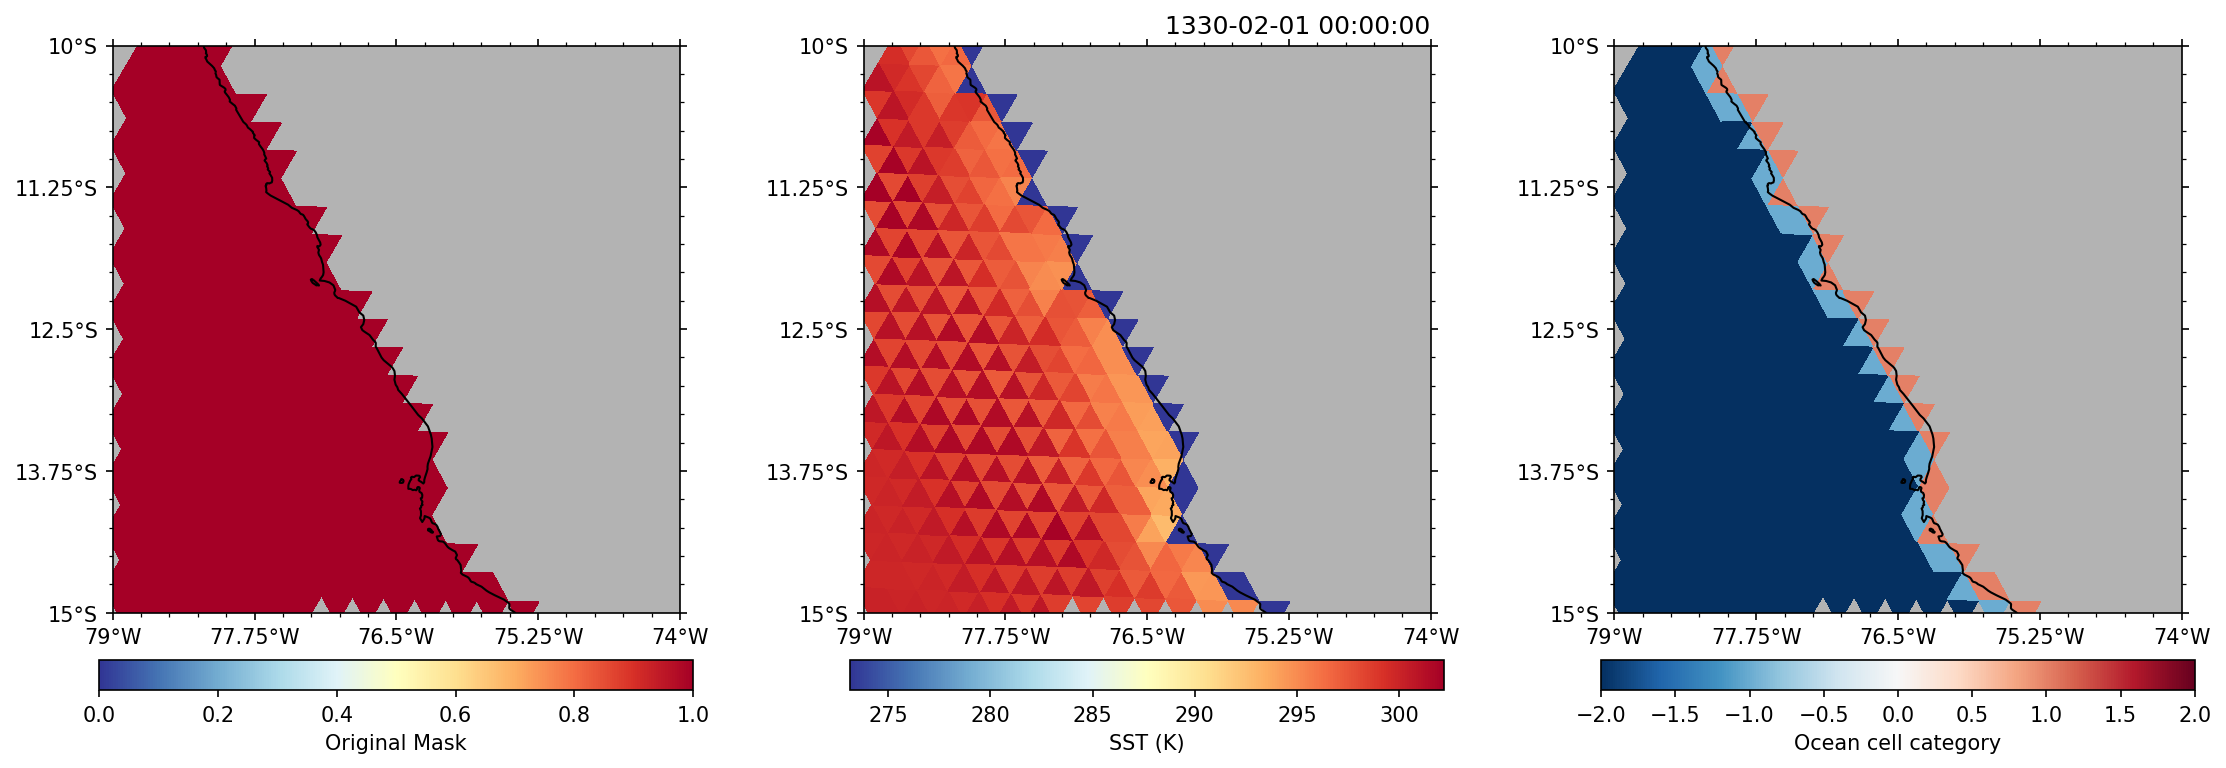

In [45]:
# check the oce_grid_ref points around the shore
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()

ax1, hm1 = ds_mask_oce['pc_all'].pyic.plot(
    ax=axes[0],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    # title_right="",
    clim=[0,1],
)
cbar1 = fig.colorbar(hm1[0], ax=axes[0], orientation="horizontal", pad=0.02, shrink=0.85,)
cbar1.set_label("Original Mask")

# check the real ocean output

tos_test = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_2d_1330-1345.nc')['tos']
ax2, hm2 = tos_test.isel(time=0).pyic.plot(
    ax=axes[1],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    # title_right="",
)
cbar2 = fig.colorbar(hm2[0], ax=axes[1], orientation="horizontal", pad=0.02, shrink=0.85,)
cbar2.set_label("SST (K)")

# cell_sea_land_mask from tgrid file for ocean r2b7
oce_grid_ref2 = xr.open_dataset(fpath_tgrid['oce'])['cell_sea_land_mask']
oce_grid_ref2 = oce_grid_ref2.rename({'cell': 'ncells'})
ax3, hm3 = oce_grid_ref2.pyic.plot(
    ax=axes[2],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    clim=[-2,2],
)
cbar3 = fig.colorbar(hm3[0], ax=axes[2], orientation="horizontal", pad=0.02, shrink=0.85,)
cbar3.set_label("Ocean cell category")

outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Oce-grid_Masks_before_correction.png" 
plt.savefig(outfile, dpi=150, bbox_inches="tight") 


- It is clear that the original regional mask based on the `fpath_tgrid['oce']['cell_area']` has land boundary cells
- Use the `fpath_tgrid['oce']['cell_sea_land_mask']` to correct it
    - when `fpath_tgrid['oce']['cell_sea_land_mask'] == -1 or -2`, it is ocean boundary and ocean grid (inner ocean)


### After correction

In [40]:
oce_valid_mask = (oce_grid_ref2 == -2) | (oce_grid_ref2 == -1)
ds_mask_oce_correct = ds_mask_oce.copy()
for region, mask in ds_mask_oce.items():
    mask_correct = mask * oce_valid_mask
    ds_mask_oce_correct[region] = mask_correct

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


/tmp/ipykernel_1690605/2008084427.py:29: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  tos_test = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_2d_1330-1345.nc')['tos']


Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


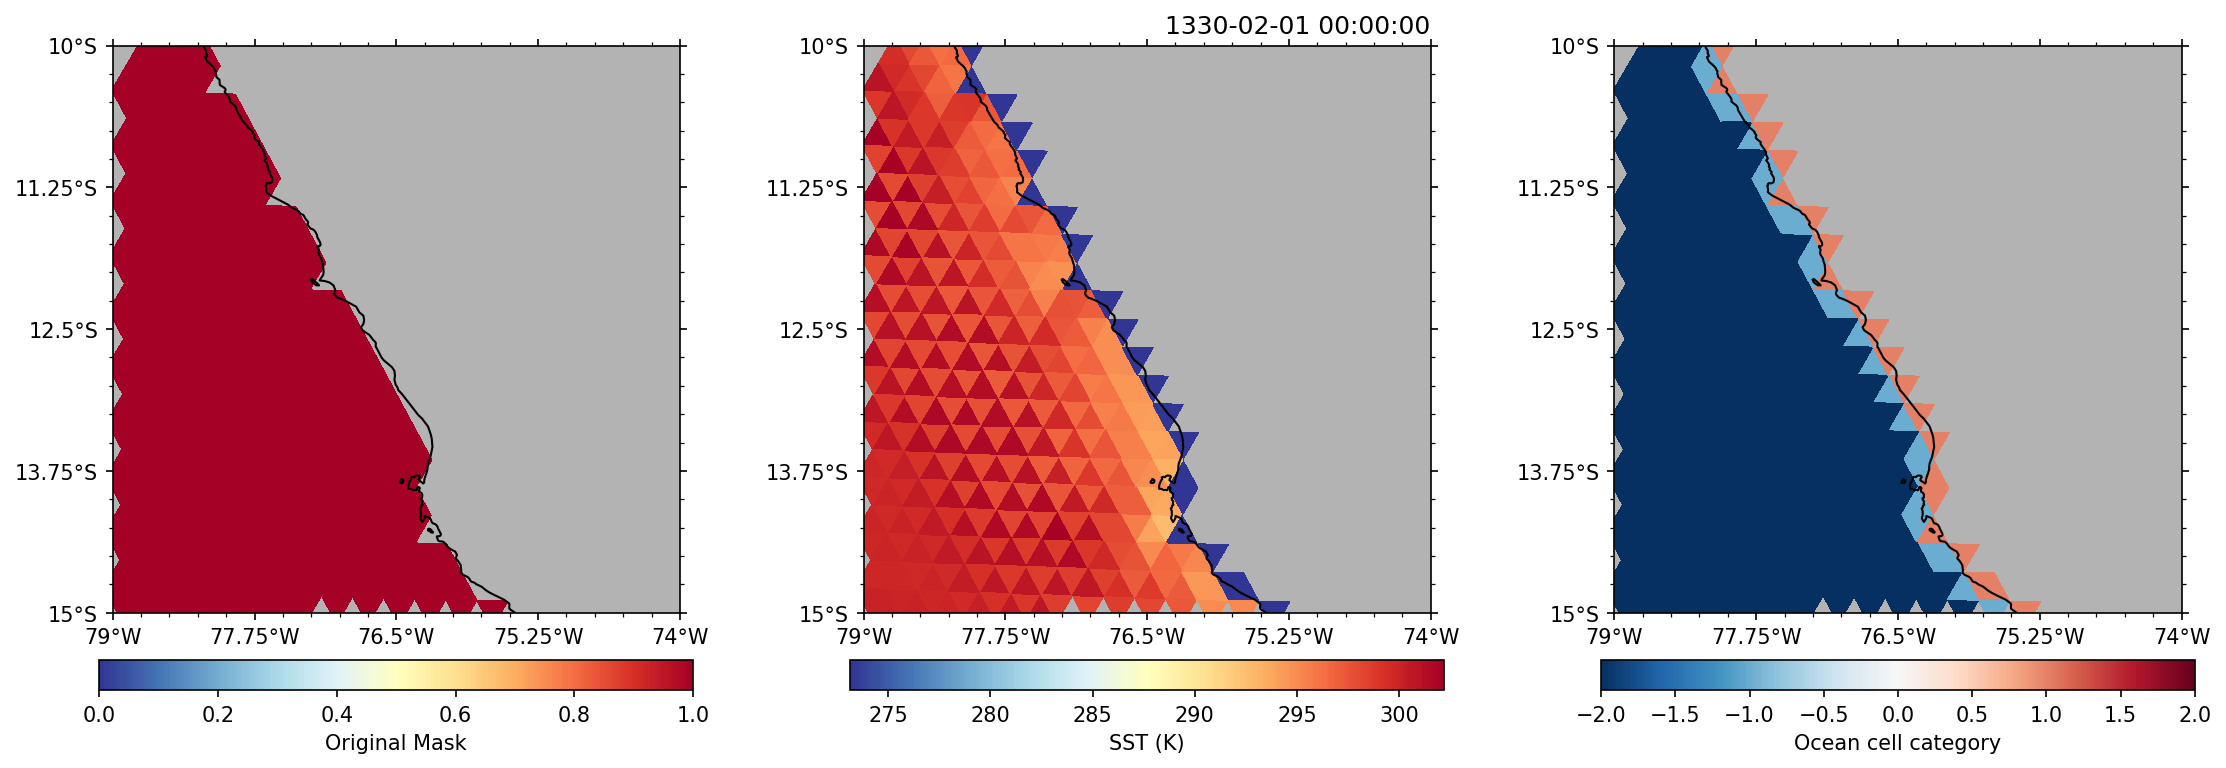

In [46]:
# check the oce_grid_ref points around the shore
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()

ax1, hm1 = ds_mask_oce_correct['pc_all'].pyic.plot(
    ax=axes[0],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    # title_right="",
    clim=[0,1],
)
cbar1 = fig.colorbar(hm1[0], ax=axes[0], orientation="horizontal", pad=0.02, shrink=0.85,)
cbar1.set_label("Original Mask")

# check the real ocean output

tos_test = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_2d_1330-1345.nc')['tos']
ax2, hm2 = tos_test.isel(time=0).pyic.plot(
    ax=axes[1],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    # title_right="",
)
cbar2 = fig.colorbar(hm2[0], ax=axes[1], orientation="horizontal", pad=0.02, shrink=0.85,)
cbar2.set_label("SST (K)")

# cell_sea_land_mask from tgrid file for ocean r2b7
oce_grid_ref2 = xr.open_dataset(fpath_tgrid['oce'])['cell_sea_land_mask']
oce_grid_ref2 = oce_grid_ref2.rename({'cell': 'ncells'})
ax3, hm3 = oce_grid_ref2.pyic.plot(
    ax=axes[2],
    cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    clim=[-2,2],
)
cbar3 = fig.colorbar(hm3[0], ax=axes[2], orientation="horizontal", pad=0.02, shrink=0.85,)
cbar3.set_label("Ocean cell category")

outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Oce-grid_Masks_after_correction.png" 
plt.savefig(outfile, dpi=150, bbox_inches="tight") 


## Nils' suggestion: using fx file with the variable `wet_c` 
- Files can be found in `/work/bm1548/m300602/pyicon_data/grids`
- the variable `wet_c` which is 1 for water and zero for land and it contains depth coordinate -> contains the information for bathmetry

In [ ]:
# read the fx files
oce_fx_files = xr.open_dataset("/work/bm1548/m300602/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_L72_fx.nc")

In [25]:
# specify the masks in each ocean layer in r2b7 configuration
oce_mask_with_depth = oce_fx_files["wet_c"]

### Check if apply the masks with only (ncells), can the variables with depth coordinate can match with the bathymetry

#### variable with depth coordinate (e.g., to)

In [39]:
# read variable with depth coordinate
to = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_to_1330-1345_mean.nc")["to"]
# read mask with only ncells
ds_mask_oce = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce.nc") 
# read mask that also consider the land boudanry point
ds_mask_oce2 = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce_with_landboundary.nc") 

to_masked = to.where(ds_mask_oce["pc_all"] == 1.0)
to_masked2 = to.where(ds_mask_oce2["pc_all"] == 1.0)

/tmp/ipykernel_290670/202304353.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  to = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_to_1330-1345_mean.nc")["to"]


Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


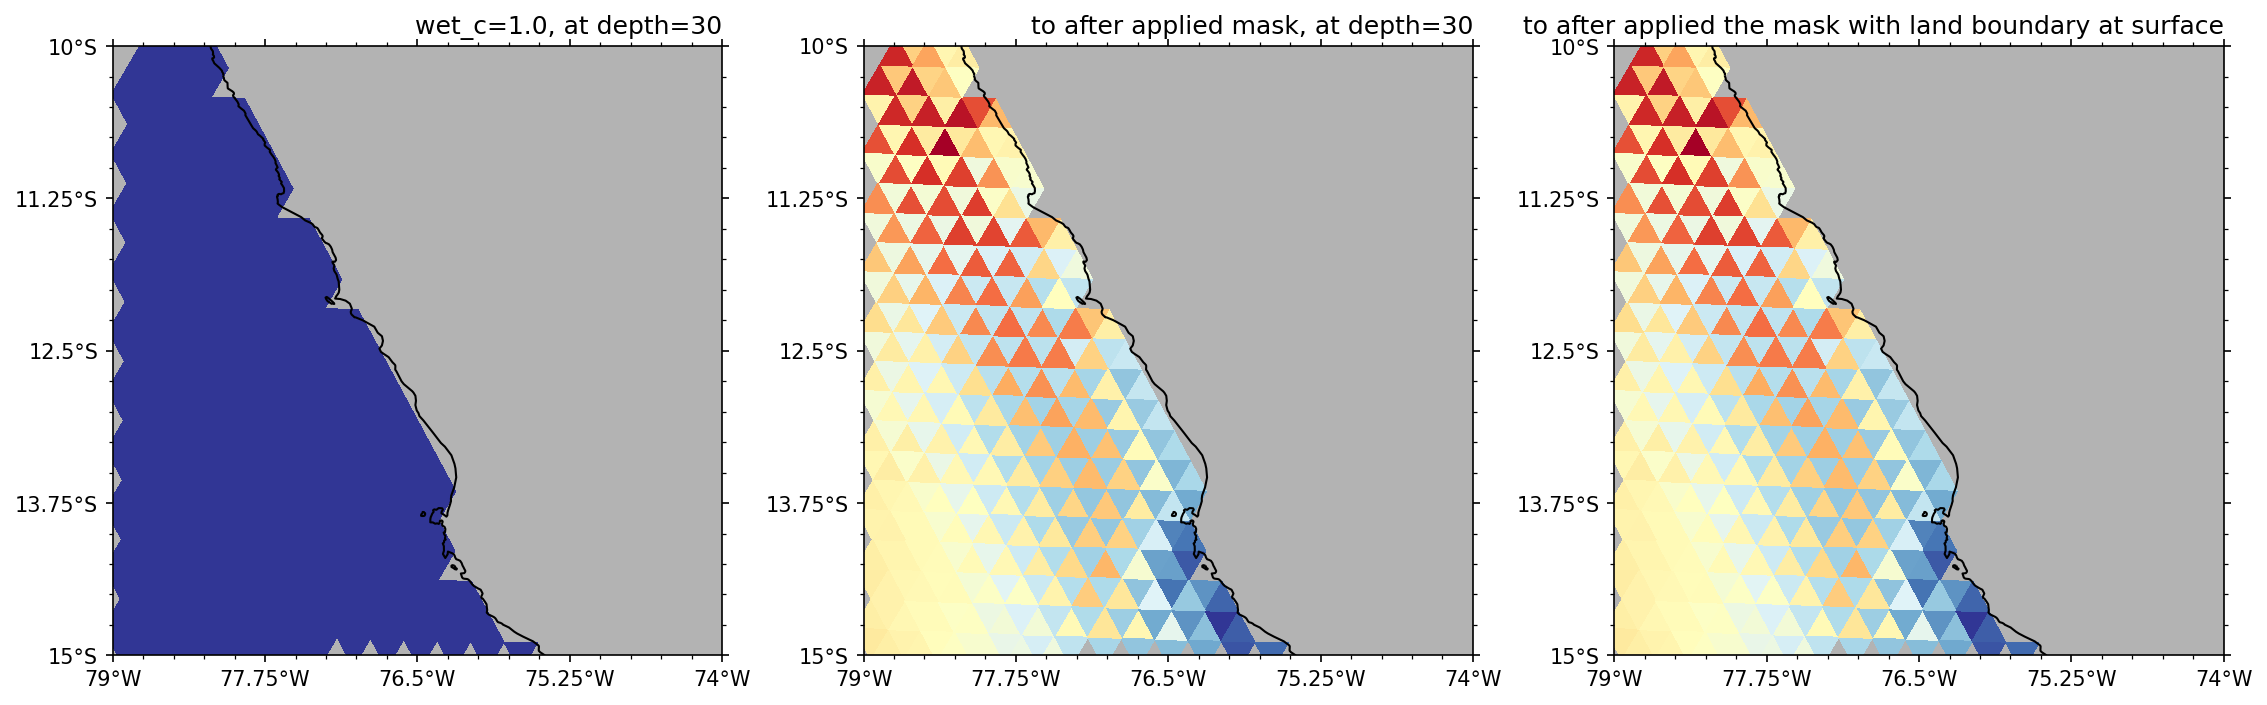

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True,
                         dpi=150,)
axes = axes.flatten()

# check the surface grid
ax1, hm1 = oce_mask_with_depth.isel(depth=0).pyic.plot(
    ax=axes[0], cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    title_right="wet_c=1.0, at depth=30",
    # clim=[0,1],
)

ax2, hm2 = to_masked.isel(time=0, depth_2=0).pyic.plot(
    ax=axes[1], cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    title_right="to after applied mask, at depth=30"
)

ax3, hm3 = to_masked2.isel(time=0, depth_2=0).pyic.plot(
    ax=axes[2], cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    title_right="to after applied the mask with land boundary at surface"
)


#### surface variable (e.g., tos)

/tmp/ipykernel_290670/4015639674.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  tos = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_2d_1330-1345.nc')['tos'].isel(time=0)


Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


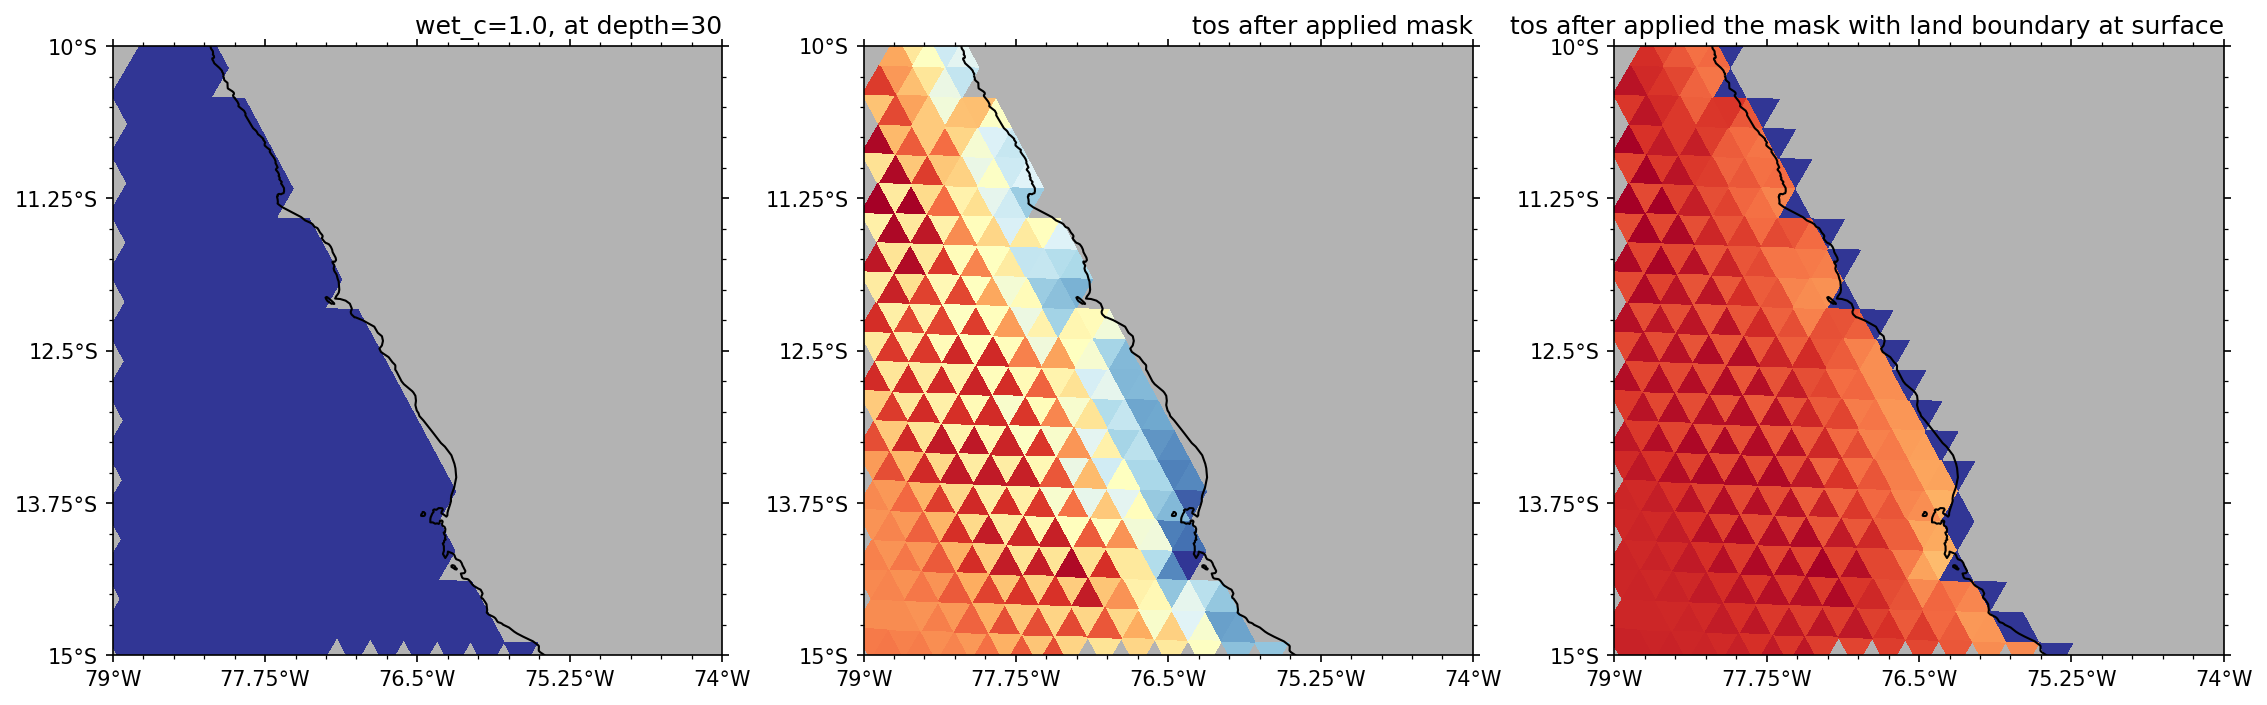

In [45]:
tos = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/processed_data/mux0001_b5b7/mux0001_b5b7_oce_def_2d_1330-1345.nc')['tos'].isel(time=0)

tos_masked = tos.where(ds_mask_oce["pc_all"] == 1.0)
tos_masked2 = tos.where(ds_mask_oce2["pc_all"] == 1.0)

fig, axes = plt.subplots(1, 3, figsize=(15,5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True,
                         dpi=150,)
axes = axes.flatten()

# check the surface grid
ax1, hm1 = oce_mask_with_depth.isel(depth=0).pyic.plot(
    ax=axes[0], cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    title_right="wet_c=1.0, at depth=30",
    # clim=[0,1],
)

ax2, hm2 = tos_masked.pyic.plot(
    ax=axes[1], cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    title_right="tos after applied mask"
)

ax3, hm3 = tos_masked2.pyic.plot(
    ax=axes[2], cax=0,
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-79, -74],
    lat_reg=[-15, -10],
    title_right="tos after applied the mask with land boundary at surface"
)


#### Summary
- When **using ['cell_sea_land_mask'] to generate the mask, it performs the same with ['wet_c'] that has depth coordinate.**
    - This is because when using interior oceanic variables (e.g., to) times the mask, because the oceanic variable already consider the bathymetry, it performs the same with the mask that has depth coordinate (using ["wet_c"] to define)
- However, **if using ['cell_area'] to generate the mask it will consider the land boundary grid cells at the surface**, which will influence the analysis against surface variables (e.g., ['tos'], and ['sos'])
- It is **still worth to get a mask file consider depth space**

### Generate new mask file considering depth space

In [54]:
# oce_mask_with_depth -> 3D mask for ocean interior
# ds_mask_oce -> 2D regional masks

In [53]:
# check if the dims (clon and clat) matches
lon_equal = np.allclose(
    ds_mask_oce["clon"].values,
    oce_mask_with_depth["clon"].values,
    rtol=0,
    atol=1e-10
)
print("clon identical:", lon_equal)

lat_equal = np.allclose(
    ds_mask_oce["clat"].values,
    oce_mask_with_depth["clat"].values,
    rtol=0,
    atol=1e-10
)
print("clat identical:", lat_equal)

clon identical: True
clat identical: True


In [55]:
# create new 3d mask dataset
ds_mask_oce_3d = xr.Dataset(
    coords={
        "depth": oce_mask_with_depth.depth,
        "ncells": ds_mask_oce.ncells,
        "clon": ds_mask_oce.clon,
        "clat": ds_mask_oce.clat,
    }
)

for v in ds_mask_oce.data_vars:
    # expand (ncells) -> (depth, ncells) and apply bathymetry
    ds_mask_oce_3d[v] = (
        ds_mask_oce[v]
        .expand_dims(depth=oce_mask_with_depth.depth)
        * oce_mask_with_depth
    )

    # Keep attributes
    ds_mask_oce_3d[v].attrs = ds_mask_oce[v].attrs

### Check if correct

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


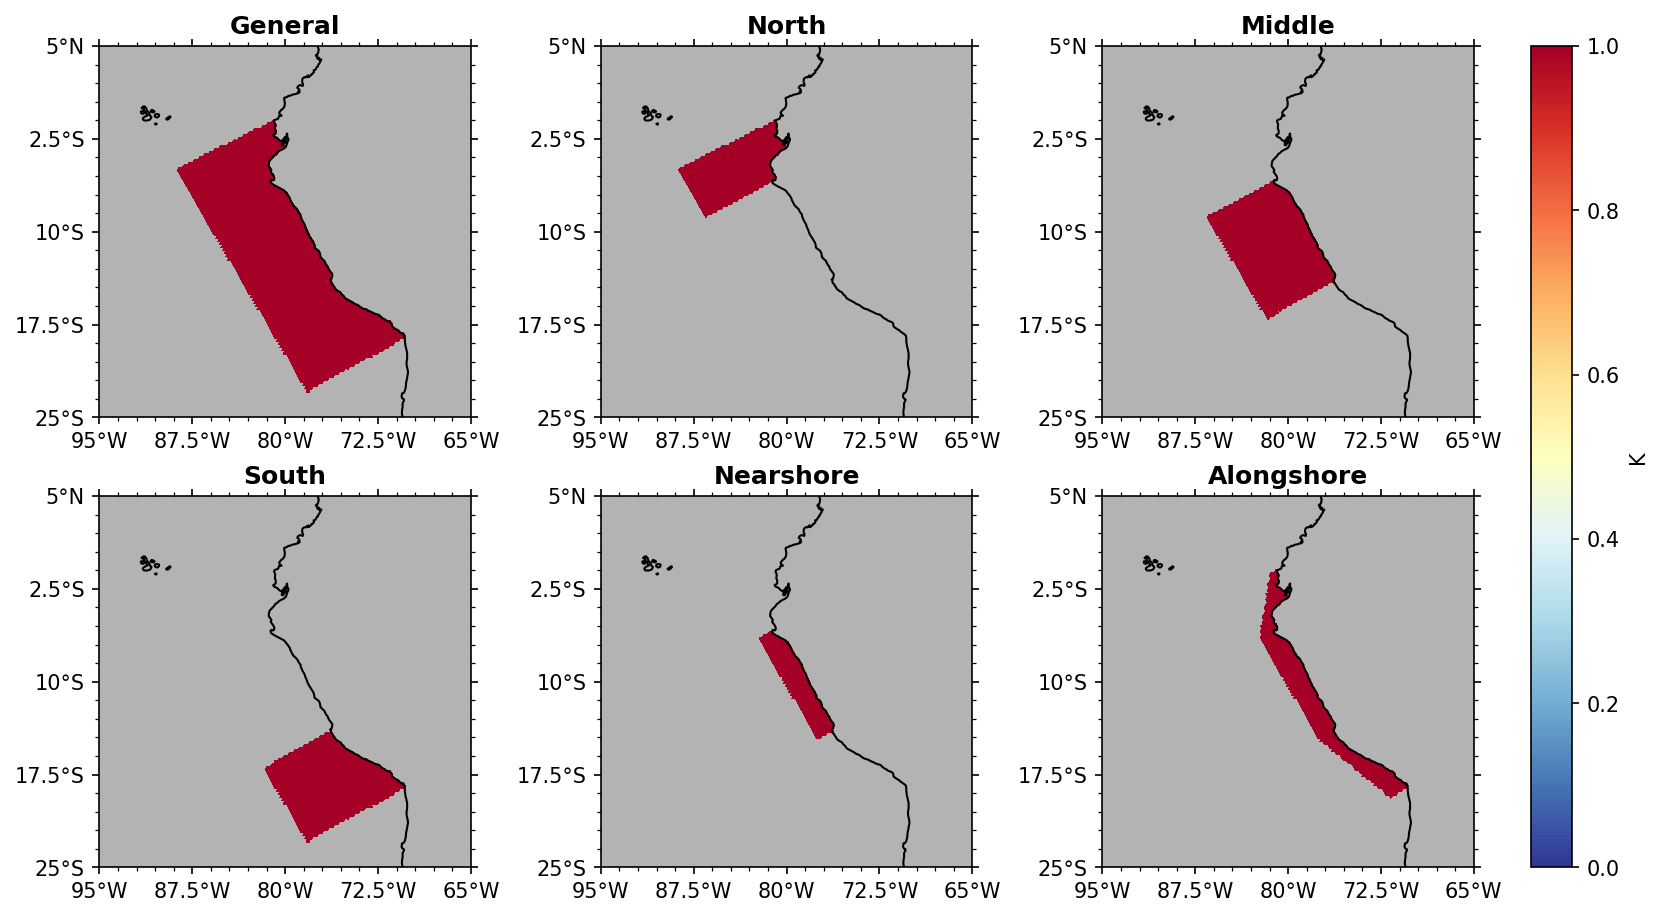

In [ ]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(11, 6),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()
masks = {'General': ds_mask_oce_3d['pc_all'],
         'North': ds_mask_oce_3d['pc_north'],
         'Middle': ds_mask_oce_3d['pc_mid'],
         'South': ds_mask_oce_3d['pc_south'],
         'Nearshore': ds_mask_oce_3d['pc_nearshore'],
         'Alongshore': ds_mask_oce_3d['pc_alongshore'],}

hm_all = []
for ax, (name, mask) in zip(axes, masks.items()):
    # t_2m_masked = t_2m_test.where(mask == 1.0)
    ax, hm = mask.isel(depth=30).pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['oce'],
        fpath_ckdtree=fpath_ckdtree['oce'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        plot_method='tgrid',
        land_facecolor='none',
        title_right="",
        clim=[0, 1],
    )
    hm_all.append(hm)
    ax.set_title(name, fontsize=12, fontweight='bold')


cbar = fig.colorbar(hm_all[0][0], ax=axes, orientation='vertical', label="K", pad=0.02, ) 
# outpath = "/home/m/m301254/project_surfwaves/figs" 
# outfile = f"{outpath}/Peruvian_Coast_Oce-grid_Masks.png" 
# plt.savefig(outfile, dpi=300, bbox_inches="tight") 
# plt.show()

In [67]:
# modify the attributes
ds_mask_oce['pc_all'].attrs={
    'standard_name': 'peru_coast_mask',
    'long_name': '2D Regional mask for the Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_north'].attrs={
    'standard_name': 'north_peru_coast_mask',
    'long_name': '2D Regional mask for the northern Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_south'].attrs={
    'standard_name': 'south_peru_coast_mask',
    'long_name': '2D Regional mask for the southern Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_mid'].attrs={
    'standard_name': 'middle_peru_coast_mask',
    'long_name': '2D Regional mask for the middle Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_nearshore'].attrs={
    'standard_name': 'peru_nearshore_mask',
    'long_name': '2D Regional mask for the near shore part of Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_alongshore'].attrs={
    'standard_name': 'peru_alongshore_mask',
    'long_name': '2D Regional mask for the along shore part of Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}

ds_mask_oce

<xarray.Dataset> Size: 60MB
Dimensions:        (ncells: 935760)
Coordinates:
    clon           (ncells) float64 7MB 1.274 1.282 1.274 ... 1.337 1.33 1.333
    clat           (ncells) float64 7MB 1.259 1.257 1.261 ... -0.7932 -0.7888
Dimensions without coordinates: ncells
Data variables:
    pc_all         (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_north       (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_mid         (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_south       (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_nearshore   (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_alongshore  (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [68]:
# modify the attributes
ds_mask_oce_3d['pc_all'].attrs={
    'standard_name': 'peru_coast_mask',
    'long_name': '3D Regional mask for the Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce_3d['pc_north'].attrs={
    'standard_name': 'north_peru_coast_mask',
    'long_name': '3D Regional mask for the northern Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce_3d['pc_south'].attrs={
    'standard_name': 'south_peru_coast_mask',
    'long_name': '3D Regional mask for the southern Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce_3d['pc_mid'].attrs={
    'standard_name': 'middle_peru_coast_mask',
    'long_name': '3D Regional mask for the middle Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce_3d['pc_nearshore'].attrs={
    'standard_name': 'peru_nearshore_mask',
    'long_name': '3D Regional mask for the near shore part of Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce_3d['pc_alongshore'].attrs={
    'standard_name': 'peru_alongshore_mask',
    'long_name': '3D Regional mask for the along shore part of Peruvian Coast (r2b7)',
    'CDI_grid_type': 'unstructured',
}

ds_mask_oce_3d

<xarray.Dataset> Size: 3GB
Dimensions:        (depth: 72, ncells: 935760)
Coordinates:
  * depth          (depth) float64 576B 1.0 3.1 5.45 ... 5.546e+03 5.816e+03
  * ncells         (ncells) int64 7MB 0 1 2 3 4 ... 935756 935757 935758 935759
    clon           (ncells) float64 7MB 1.274 1.282 1.274 ... 1.337 1.33 1.333
    clat           (ncells) float64 7MB 1.259 1.257 1.261 ... -0.7932 -0.7888
Data variables:
    pc_all         (depth, ncells) float64 539MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    pc_north       (depth, ncells) float64 539MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    pc_mid         (depth, ncells) float64 539MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    pc_south       (depth, ncells) float64 539MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    pc_nearshore   (depth, ncells) float64 539MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    pc_alongshore  (depth, ncells) float64 539MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [69]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks"
ds_mask_oce.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_oce_2d.nc")
ds_mask_oce_3d.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_oce_3d.nc")

# Cross-sections in Ocean grid
- define the cross-sections (line) that almost prependicular to the coast
- file name: Peruvian_Coast_cross-section_1/2/3.txt

## First try on cross-section 1

In [ ]:
import shapely.ops as ops
from pyproj import CRS, Transformer

# load the line file
cs1 = np.loadtxt("/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_cross-section_1.txt")
cs1_ll = shpg.LineString(cs1)

# projection centered on Peru
proj_ll = CRS.from_epsg(4326)
proj_m  = CRS.from_proj4("+proj=aeqd +lat_0=-11 +lon_0=-80 +datum=WGS84")
T_to_m = Transformer.from_crs(proj_ll, proj_m, always_xy=True)
T_to_ll = Transformer.from_crs(proj_m, proj_ll, always_xy=True)

# project line to meters
line_m = ops.transform(T_to_m.transform, cs1_ll)

# width of transect (e.g. 20 km)
width_km = 20
buffer_m = (width_km * 1000) / 2

# create transect swath
transect_m = line_m.buffer(buffer_m)

# back to lon/lat
transect_ll = ops.transform(T_to_ll.transform, transect_m)

# grid reference 1
oce_grid_ref = xr.open_dataset(fpath_tgrid['oce'])['cell_area']
oce_grid_ref = oce_grid_ref.rename({'cell': 'ncells'})
oce_points = np.column_stack((
    oce_grid_ref.clon.values * 180 / np.pi,
    oce_grid_ref.clat.values * 180 / np.pi
))
ds_mask_cs = xr.Dataset()
ds_mask_cs["pc_cs1"] = oce_grid_ref.copy()

for i, (lon, lat) in enumerate(oce_points):
    p = shpg.Point(lon, lat)
    if transect_ll.contains(p):
        ds_mask_cs["pc_cs1"][i] = 1.0
    else:
        ds_mask_cs["pc_cs1"][i] = 0.0

# Apply the ocean validity mask (to remove the land boundary)
oce_grid_ref2 = xr.open_dataset(fpath_tgrid['oce'])['cell_sea_land_mask']
oce_grid_ref2 = oce_grid_ref2.rename({'cell': 'ncells'})
oce_valid_mask = (oce_grid_ref2 == -2) | (oce_grid_ref2 == -1)
ds_mask_cs["pc_cs1"] = ds_mask_cs["pc_cs1"] * oce_valid_mask


In [8]:
ds_mask_cs

<xarray.Dataset> Size: 22MB
Dimensions:  (ncells: 935760)
Coordinates:
    clon     (ncells) float64 7MB 1.274 1.282 1.274 1.266 ... 1.337 1.33 1.333
    clat     (ncells) float64 7MB 1.259 1.257 1.261 ... -0.793 -0.7932 -0.7888
Dimensions without coordinates: ncells
Data variables:
    pc_cs1   (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: title={'right': 'cross-section1'}>,
  <matplotlib.colorbar.Colorbar at 0x7f1e75457710>])

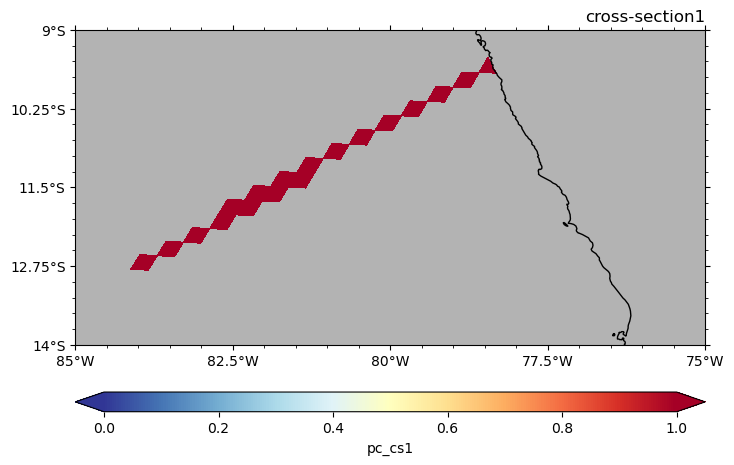

In [ ]:
# check the mask
ds_mask_cs["pc_cs1"].pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    title_right="cross-section1",
    clim=[0,1],
)

## Add cross-section 2&3

In [19]:
# read files
cs2 = np.loadtxt("/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_cross-section_2.txt")
cs3 = np.loadtxt("/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_cross-section_3.txt")
cs2_ll = shpg.LineString(cs2)
cs3_ll = shpg.LineString(cs3)

# dict
cs_all = {"pc_cs1": cs1_ll,
        "pc_cs2": cs2_ll,
        "pc_cs3": cs3_ll}

# for loop
ds_mask_cs = xr.Dataset()
for cs, ll in cs_all.items():
        # project line to meters
        line_m = ops.transform(T_to_m.transform, ll)
        # width of transect (e.g. 20 km)
        width_km = 20
        buffer_m = (width_km * 1000) / 2

        # create transect swath
        transect_m = line_m.buffer(buffer_m)
        # back to lon/lat
        transect_ll = ops.transform(T_to_ll.transform, transect_m)

        # grid reference 1
        oce_points = np.column_stack((
        oce_grid_ref.clon.values * 180 / np.pi,
        oce_grid_ref.clat.values * 180 / np.pi
        ))
        # ds_mask_cs = xr.Dataset()
        ds_mask_cs[cs] = oce_grid_ref.copy()

        for i, (lon, lat) in enumerate(oce_points):
                p = shpg.Point(lon, lat)
                if transect_ll.contains(p):
                        ds_mask_cs[cs][i] = 1.0
                else:
                        ds_mask_cs[cs][i] = 0.0

        # Apply the ocean validity mask (to remove the land boundary)
        # oce_valid_mask = (oce_grid_ref2 == -2) | (oce_grid_ref2 == -1)
        ds_mask_cs[cs] = ds_mask_cs[cs] * oce_valid_mask

In [20]:
ds_mask_cs

<xarray.Dataset> Size: 37MB
Dimensions:  (ncells: 935760)
Coordinates:
    clon     (ncells) float64 7MB 1.274 1.282 1.274 1.266 ... 1.337 1.33 1.333
    clat     (ncells) float64 7MB 1.259 1.257 1.261 ... -0.793 -0.7932 -0.7888
Dimensions without coordinates: ncells
Data variables:
    pc_cs1   (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    pc_cs2   (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    pc_cs3   (ncells) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


<Figure size 1200x900 with 0 Axes>

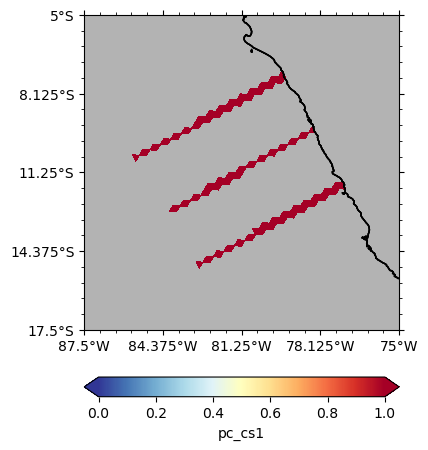

In [33]:
# Define colors
cmaps = {"pc_cs1": "Reds",
          "pc_cs2": "Blues",
          "pc_cs3": "Greens"
}

# --- Create base figure ---
fig = plt.figure(figsize=(8, 6), dpi=150)

# Use a dummy plot to initialize the map (empty base)
ax, _ = (ds_mask_cs["pc_cs1"] * 0).pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    plot_method="tgrid",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    land_facecolor="none",
    clim=[0, 1],
    title_right=""
)

# --- Overlay each cross-section mask ---
for name, cmap in cmaps.items():
    ds_mask_cs[name].pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid["oce"],
        fpath_ckdtree=fpath_ckdtree["oce"],
        plot_method="tgrid",
        lon_reg=[-87.5, -75],
        lat_reg=[-17.5, -5],
        land_facecolor="none",
        clim=[0, 1],
        # cmap=cmap,
    )

outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Peruvian_Coast_cross-section_Masks.png" 
plt.savefig(outfile, dpi=150, bbox_inches="tight") 


In [34]:
# also consider the depth coordinate, make another version
# fx files
oce_fx_files = xr.open_dataset("/work/bm1548/m300602/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_L72_fx.nc")
oce_mask_with_depth = oce_fx_files["wet_c"]


In [36]:
# create new 3d mask dataset
ds_mask_cs_3d = xr.Dataset(
    coords={
        "depth": oce_mask_with_depth.depth,
        "ncells": ds_mask_cs.ncells,
        "clon": ds_mask_cs.clon,
        "clat": ds_mask_cs.clat,
    }
)

for v in ds_mask_cs.data_vars:
    # expand (ncells) -> (depth, ncells) and apply bathymetry
    ds_mask_cs_3d[v] = (
        ds_mask_cs[v]
        .expand_dims(depth=oce_mask_with_depth.depth)
        * oce_mask_with_depth
    )

Deriving triangulation object, this can take a while...
Done deriving triangulation object.


(<GeoAxes: title={'right': 'cross-section1'}>,
  <matplotlib.colorbar.Colorbar at 0x7f1e65217b90>])

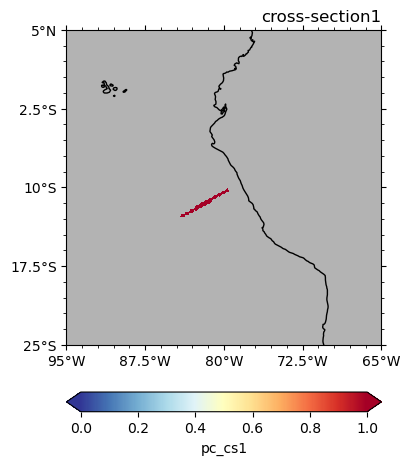

In [41]:
# check the mask
ds_mask_cs_3d["pc_cs1"].isel(depth=60).pyic.plot(
    fpath_tgrid=fpath_tgrid["oce"],
    fpath_ckdtree=fpath_ckdtree["oce"],
    land_facecolor="none",
    plot_method="tgrid",
    lon_reg=[-95, -65],
    lat_reg=[-25, 5],
    title_right="cross-section1",
    clim=[0,1],
)

## Save to nc files

In [42]:
# save both 2D and 3D mask for cross-sections
outpath = "/work/mh0033/m301254/proj_surfwave/masks"
ds_mask_cs.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_cs_2d.nc")
ds_mask_cs_3d.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_cs_3d.nc")

# Final atm (r2b5) and oce (r2b7) regional masks

## atm

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


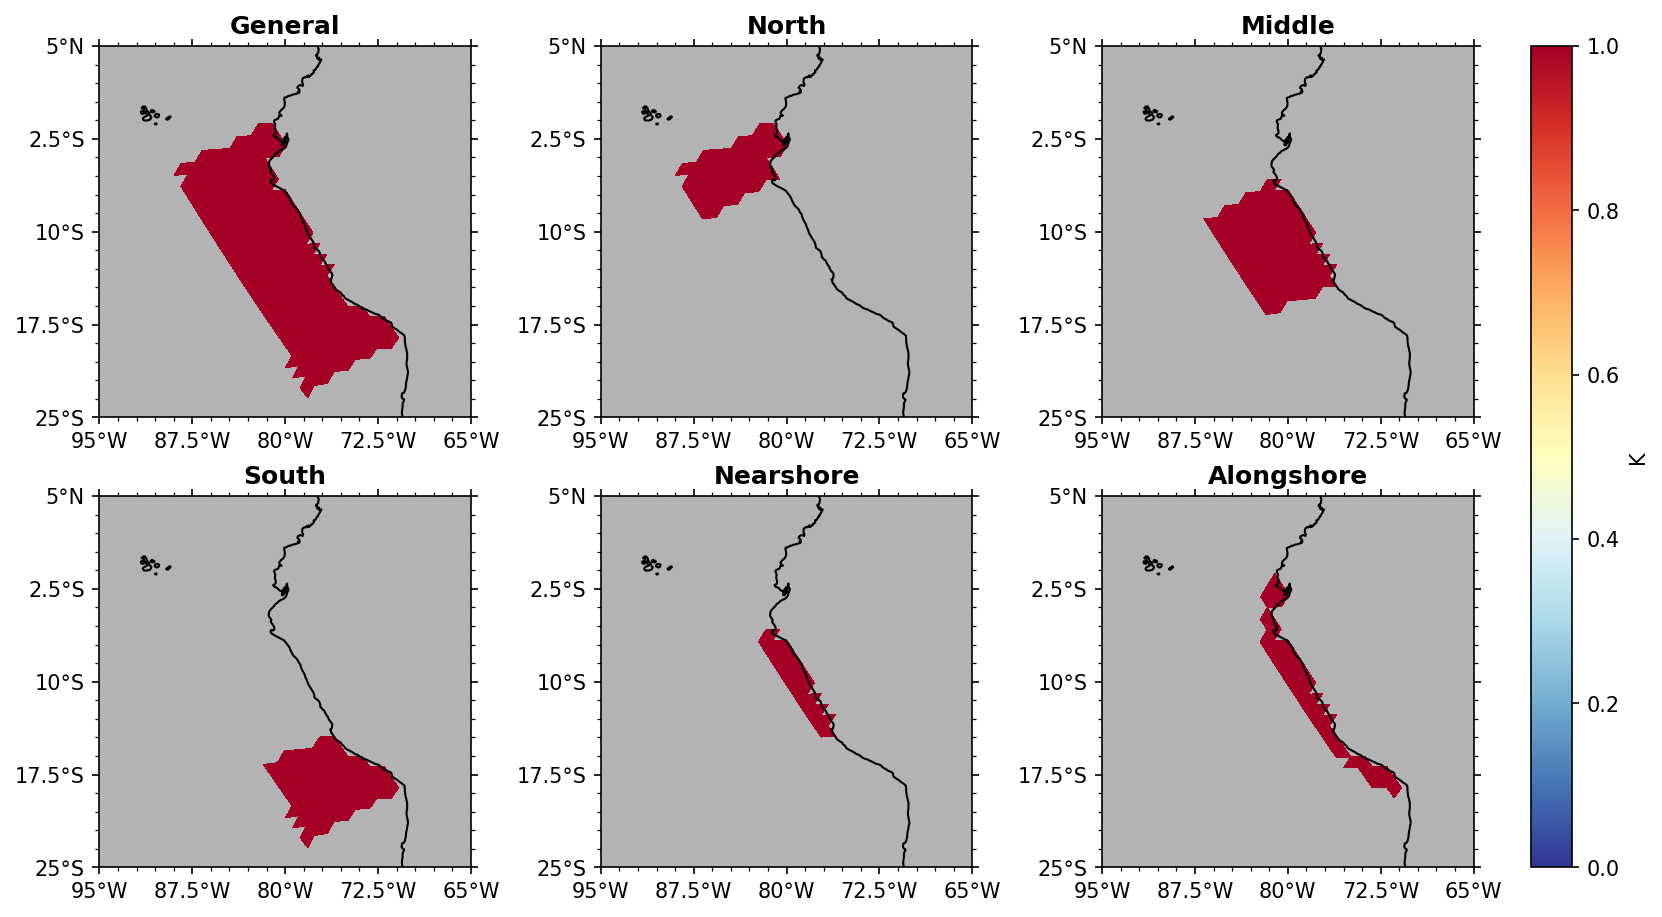

In [52]:
ds_mask_atm = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_atm.nc")

fig, axes = plt.subplots(
    2, 3,
    figsize=(11, 6),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()
masks = {'General': ds_mask_atm['pc_all'],
         'North': ds_mask_atm['pc_north'],
         'Middle': ds_mask_atm['pc_mid'],
         'South': ds_mask_atm['pc_south'],
         'Nearshore': ds_mask_atm['pc_nearshore'],
         'Alongshore': ds_mask_atm['pc_alongshore'],}

hm_all = []
for ax, (name, mask) in zip(axes, masks.items()):
    # t_2m_masked = t_2m_test.where(mask == 1.0)
    ax, hm = mask.pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['atm'],
        fpath_ckdtree=fpath_ckdtree['atm'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        plot_method='tgrid',
        land_facecolor='none',
        title_right="",
        clim=[0, 1],
    )
    hm_all.append(hm)
    ax.set_title(name, fontsize=12, fontweight='bold')


cbar = fig.colorbar(hm_all[0][0], ax=axes, orientation='vertical', label="K", pad=0.02, ) 
outpath = "/home/m/m301254/project_surfwaves/figs/peruvian_coast_masks" 
outfile = f"{outpath}/Peruvian_Coast_Atm-grid_Masks_.png" 
plt.savefig(outfile, dpi=150, bbox_inches="tight") 
# plt.show()

## oce

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


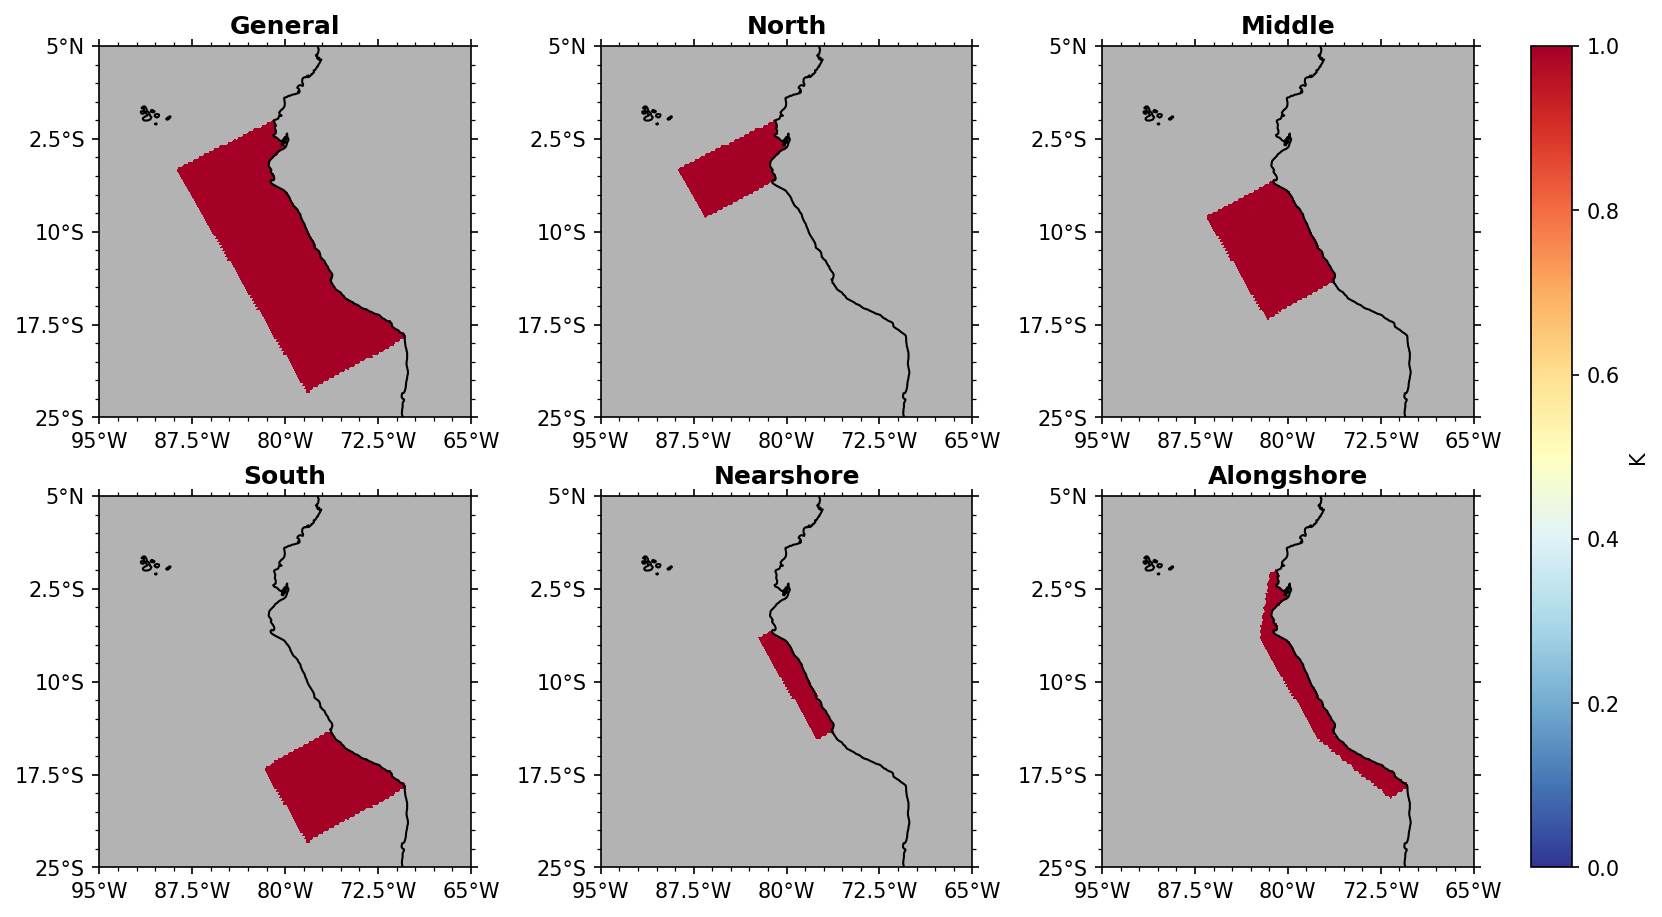

In [44]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(11, 6),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()
masks = {'General': ds_mask_oce_correct['pc_all'],
         'North': ds_mask_oce_correct['pc_north'],
         'Middle': ds_mask_oce_correct['pc_mid'],
         'South': ds_mask_oce_correct['pc_south'],
         'Nearshore': ds_mask_oce_correct['pc_nearshore'],
         'Alongshore': ds_mask_oce_correct['pc_alongshore'],}

hm_all = []
for ax, (name, mask) in zip(axes, masks.items()):
    # t_2m_masked = t_2m_test.where(mask == 1.0)
    ax, hm = mask.pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['oce'],
        fpath_ckdtree=fpath_ckdtree['oce'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        plot_method='tgrid',
        land_facecolor='none',
        title_right="",
        clim=[0, 1],
    )
    hm_all.append(hm)
    ax.set_title(name, fontsize=12, fontweight='bold')


cbar = fig.colorbar(hm_all[0][0], ax=axes, orientation='vertical', label="K", pad=0.02, ) 
outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Peruvian_Coast_Oce-grid_Masks_corrected.png" 
plt.savefig(outfile, dpi=300, bbox_inches="tight") 
# plt.show()

In [49]:
outpath = "/work/mh0033/m301254/proj_surfwave/masks"
ds_mask_oce_correct.to_netcdf(f"{outpath}/peruvian_coast_regional_masks_oce_correct.nc")

Comment on 08/01/2025: I change the file name directly using shell script
- **The final netcdf filename and filepath for regional masks in atmospheric grid and ocean grid are:**
    - atmospheric grid: /work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_atm.nc
    - (corrected) oceanic grid: /work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce.nc


Comment on 18/01/2025: **Two versions of masks** were considered and created. They were 2D version (with only "ncells" dimension) and the 3D version (with "depth (oce) /height (atm)" and "ncells" as dimensions)
- Paths to **2D** regional masks in atmospheric grid and ocean grids:
    - atmospheric grid: /work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_atm_2d.nc
    - (corrected) oceanic grid: /work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce_2d.nc
- Paths to **3D** regional masks in atmospheric grid and ocean grids:
    - atmospheric grid: /work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_atm_3d.nc
    - (corrected) oceanic grid: /work/mh0033/m301254/proj_surfwave/masks/peruvian_coast_regional_masks_oce_3d.nc



# Masks for Project: Mesoscale eddies and Upwelling

## paths

In [2]:
# Define the empty dictionaries
fpath_tgrid = {}
fpath_ckdtree = {}

# info for the grids
gname_oce = 'r2b9_oce_r0004'
gname_atm = 'r2b8_atm_r0033'
# lev_oce = 'L72'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# specify the file paths for different components
fpath_tgrid['atm'] = (f'{path_grid_atm}{gname_atm}_tgrid.nc')
fpath_tgrid['oce'] = (f'{path_grid_oce}{gname_oce}_tgrid.nc')

fpath_ckdtree['atm'] = (f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc')
fpath_ckdtree['oce'] = (f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc')

In [3]:
# paths to the shape txt file
# PC_gen_path = "/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_General.txt"
# PC_nor_path = "/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_North.txt"
# PC_sou_path = "/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_South.txt"
PC_mid_path = "/home/m/m301254/project_surfwaves/docs/Peruvian_Coast_Middle.txt"
# PC_sho_path = "/home/m/m301254/project_surfwaves/docs/Peruvian_nearshore.txt"
# PC_alo_path = "/home/m/m301254/project_surfwaves/docs/Peruvian_alongshore.txt"

# PC_gen_shape = shpg.Polygon(np.loadtxt(PC_gen_path, delimiter=","))
# PC_nor_shape = shpg.Polygon(np.loadtxt(PC_nor_path, delimiter=","))
# PC_sou_shape = shpg.Polygon(np.loadtxt(PC_sou_path, delimiter=","))
PC_mid_shape = shpg.Polygon(np.loadtxt(PC_mid_path, delimiter=","))
# PC_sho_shape = shpg.Polygon(np.loadtxt(PC_sho_path, delimiter=","))
# PC_alo_shape = shpg.Polygon(np.loadtxt(PC_alo_path, delimiter=","))

## oce (r2b9)

### 2d

In [4]:
# oce grid -> filter most of the land points
oce_grid = xr.open_dataset(fpath_tgrid["oce"])["cell_area"]
oce_grid = oce_grid.rename({"cell": "ncells"})
# lon/lat in degrees
oce_points = np.column_stack((
        oce_grid.clon.values * 180.0 / np.pi,
        oce_grid.clat.values * 180.0 / np.pi,
    ))

# oce mask -> filter the "land boundary points"
oce_mask_ref = xr.open_dataset(fpath_tgrid["oce"])["cell_sea_land_mask"]
oce_mask_ref = oce_mask_ref.rename({"cell": "ncells"})
# sea (-2 inner, -1 boundary)
oce_mask = (oce_mask_ref == -2) | (oce_mask_ref == -1)

In [5]:
shapes = {
    # "pc_all": PC_gen_shape,
    # "pc_north": PC_nor_shape,
    "pc_mid": PC_mid_shape,
    # "pc_south": PC_sou_shape,
    # "pc_nearshore": PC_sho_shape,
    # "pc_alongshore": PC_alo_shape,
}
ds_mask_oce = xr.Dataset()
for region, shape in shapes.items():
    print(f"Creating mask: {region}")
    # initialize zero mask on ocean grid
    da = xr.zeros_like(oce_grid)
    # geometry test
    for i, (lon, lat) in enumerate(oce_points):
        if shape.contains(shpg.Point(lon, lat)):
            da[i] = 1.0
    # remove land boundary points
    da = da * oce_mask
    ds_mask_oce[region] = da

for v in ds_mask_oce.data_vars:
    leaked = ((ds_mask_oce[v] == 1) & (oce_mask == 0)).sum()
    print(f"{v}: land leakage = {int(leaked.values)}")

Creating mask: pc_mid
pc_mid: land leakage = 0


Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


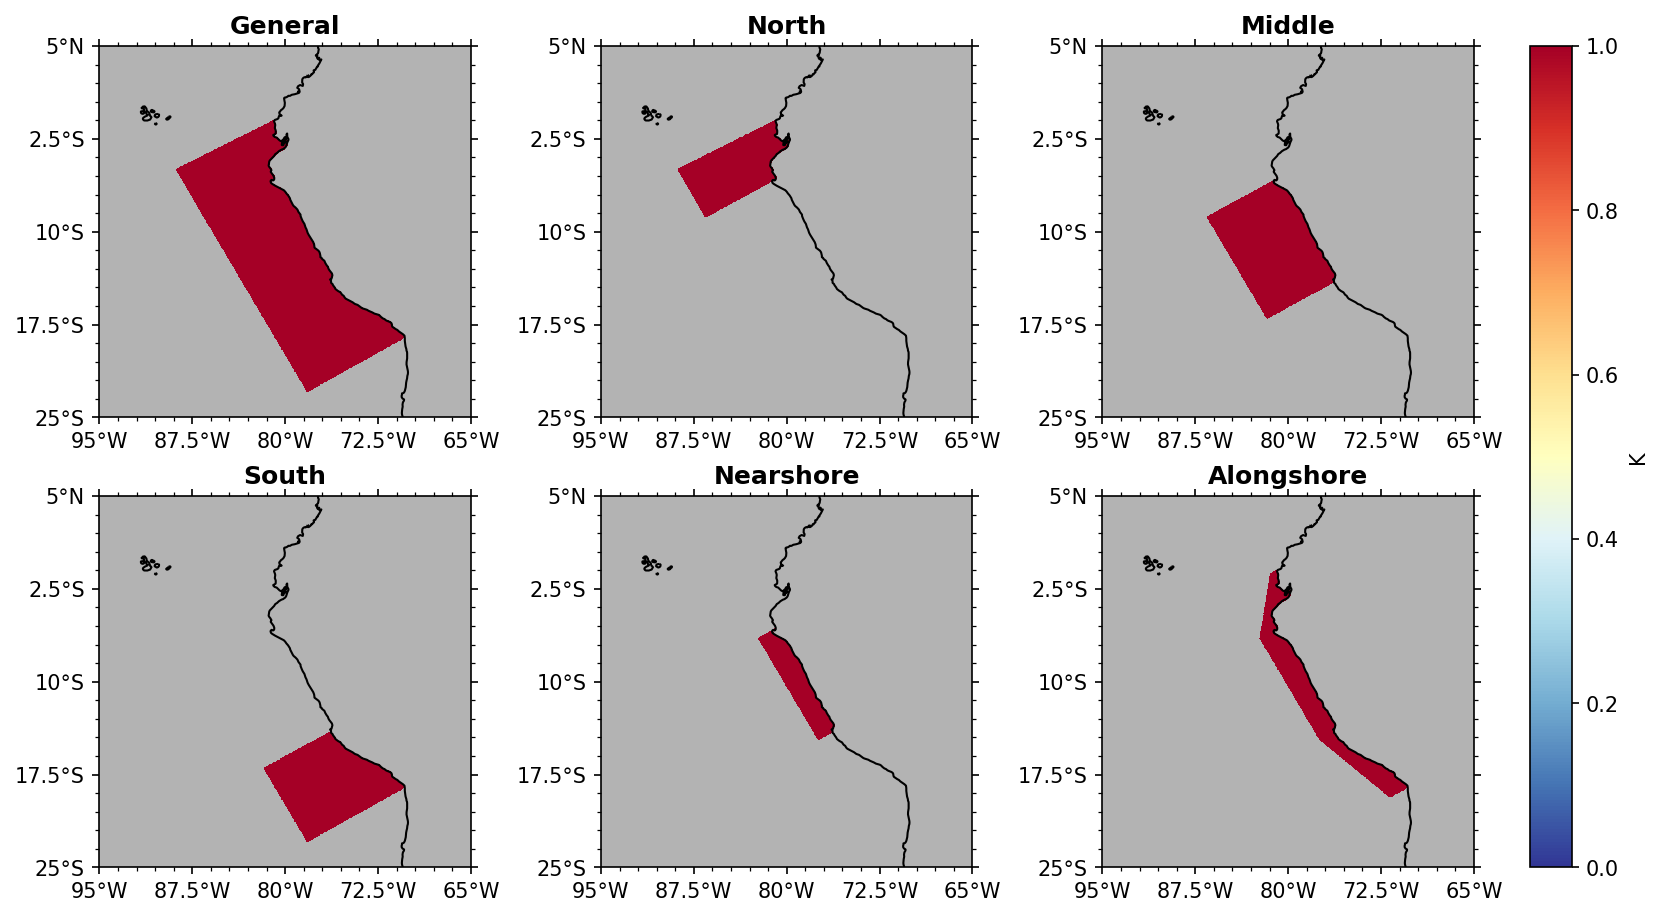

In [13]:
# check the mask
fig, axes = plt.subplots(
    2, 3,
    figsize=(11, 6),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = axes.flatten()
masks = {'General': ds_mask_oce['pc_all'],
         'North': ds_mask_oce['pc_north'],
         'Middle': ds_mask_oce['pc_mid'],
         'South': ds_mask_oce['pc_south'],
         'Nearshore': ds_mask_oce['pc_nearshore'],
         'Alongshore': ds_mask_oce['pc_alongshore'],}

hm_all = []
for ax, (name, mask) in zip(axes, masks.items()):
    # t_2m_masked = t_2m_test.where(mask == 1.0)
    ax, hm = mask.pyic.plot(
        ax=ax,
        cax=0,
        fpath_tgrid=fpath_tgrid['oce'],
        fpath_ckdtree=fpath_ckdtree['oce'],
        lon_reg=[-95, -65],
        lat_reg=[-25, 5],
        plot_method='tgrid',
        land_facecolor='none',
        title_right="",
        clim=[0, 1],
    )
    hm_all.append(hm)
    ax.set_title(name, fontsize=12, fontweight='bold')


cbar = fig.colorbar(hm_all[0][0], ax=axes, orientation='vertical', label="K", pad=0.02, ) 
outpath = "/home/m/m301254/project_surfwaves/figs" 
outfile = f"{outpath}/Peruvian_Coast_Oce-grid_Masks.png" 
# plt.savefig(outfile, dpi=300, bbox_inches="tight") 
plt.show()

In [14]:
# modify the attributes
ds_mask_oce['pc_all'].attrs={
    'standard_name': 'peru_coast_mask',
    'long_name': '2D Regional mask for the Peruvian Coast in ocean grid (r2b9)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_north'].attrs={
    'standard_name': 'north_peru_coast_mask',
    'long_name': '2D Regional mask for the northern Peruvian Coast in ocean grid (r2b9)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_south'].attrs={
    'standard_name': 'south_peru_coast_mask',
    'long_name': '2D Regional mask for the southern Peruvian Coast in ocean grid (r2b9)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_mid'].attrs={
    'standard_name': 'middle_peru_coast_mask',
    'long_name': '2D Regional mask for the middle Peruvian Coast in ocean grid (r2b9)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_nearshore'].attrs={
    'standard_name': 'peru_nearshore_mask',
    'long_name': '2D Regional mask for the near shore part of Peruvian Coast in ocean grid (r2b9)',
    'CDI_grid_type': 'unstructured',
}
ds_mask_oce['pc_alongshore'].attrs={
    'standard_name': 'peru_alongshore_mask',
    'long_name': '2D Regional mask for the along shore part of Peruvian Coast in ocean grid (r2b9)',
    'CDI_grid_type': 'unstructured',
}

ds_mask_oce

<xarray.Dataset> Size: 953MB
Dimensions:        (ncells: 14886338)
Coordinates:
    clon           (ncells) float64 119MB 1.274 1.276 1.274 ... 1.336 1.334
    clat           (ncells) float64 119MB 1.259 1.259 1.26 ... -0.7894 -0.7895
Dimensions without coordinates: ncells
Data variables:
    pc_all         (ncells) float64 119MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_north       (ncells) float64 119MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_mid         (ncells) float64 119MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_south       (ncells) float64 119MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_nearshore   (ncells) float64 119MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    pc_alongshore  (ncells) float64 119MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [21]:
outpath1 = "/work/mh0033/m301254/proj_surfwave/masks"
outpath2 = "/work/mh0033/m301254/proj_eddy_upwelling/masks"
ds_mask_oce.to_netcdf(f"{outpath1}/peruvian_coast_regional_masks_oce_r2b9_2d.nc")
ds_mask_oce.to_netcdf(f"{outpath2}/peruvian_coast_regional_masks_oce_r2b9_2d.nc")

### 3d

In [15]:
# read the fx files
oce_mask_with_depth = xr.open_dataset("/home/m/m301254/pyicon_data/grids/r2b9_oce_r0004/r2b9_oce_r0004_L72.nc")["wet_c"]

In [16]:
oce_mask_with_depth

<xarray.DataArray 'wet_c' (depth: 72, ncells: 14886338)> Size: 4GB
[1071816336 values with dtype=float32]
Coordinates:
  * depth    (depth) float64 576B 1.0 3.1 5.45 ... 5.279e+03 5.546e+03 5.816e+03
    clon     (ncells) float32 60MB ...
    clat     (ncells) float32 60MB ...
Dimensions without coordinates: ncells
Attributes:
    standard_name:                wet_c
    long_name:                    3d lsm on cells
    code:                         255
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1